# Einstiegssignale — Einzelauswertung und Kombination mit der Risikoampel

Dieses Notebook untersucht Einstiegssignale für vier Aktienindices (S&P 500, Dow
Jones, NASDAQ 100, Russell 2000) aus drei Blickwinkeln, die bewusst getrennt
betrachtet werden:

1. **Isoliert:** Wie wirkt ein einzelnes Einstiegssignal für sich genommen — ganz
   ohne Bezug zu einer Risikoampel? Schlägt der Markt danach im Schnitt eine
   bessere oder schlechtere Entwicklung ein als sonst?
2. **In Kombination mit der Risikoampel, als früher Wiedereinstieg:** Lohnt es
   sich, in einer laufenden Rot-Phase der Ampel vorzeitig wieder in den Markt
   einzusteigen, sobald ein Einstiegssignal auslöst — statt starr bis zum
   offiziellen Ende der Rot-Phase abzuwarten?
3. **Rein signalgetrieben:** Lohnt es sich, unabhängig von der aktuellen
   Ampelfarbe einzusteigen, sobald ein Einstiegssignal auslöst, die Position dann
   aber bei der nächsten **neuen** Rot-Phase wieder zu schließen?

Untersucht werden zwei Arten von Signalen: Erstens ein Signal auf Basis eines
historisch besonders hohen Anteils fallender Aktien bzw. fallenden Volumens an
den beiden großen US-Börsenplätzen NASDAQ und NYSE (Abschnitt 3) — die Idee eines
überdehnten Gummibands, das sich nach einem extremen, breiten Ausverkauf wieder
nach oben löst. Zweitens elf weitere Muster (gleitende Durchschnitte, Marktbreite,
Put/Call-Ratio, Abschnitt 4), die ursprünglich am S&P 500 beobachtet wurden, deren
zugrunde liegende Logik sich aber unverändert auf jeden der vier Indices anwenden
lässt und hier entsprechend ausgewertet wird.

Der Aufbau: Abschnitt 1 lädt die notwendigen Daten und Hilfsfunktionen. Abschnitt 2
bereitet für jeden Index die Kursdaten samt der zuvor für alle vier Indices
einheitlich ermittelten Ampel auf. Abschnitt 3 wertet das
Advancing/Declining-Signal in allen drei Blickwinkeln aus. Abschnitt 4 wertet die
übrigen elf Einstiegssignale isoliert aus (Blickwinkel 1). Abschnitt 5 zeigt je
Index einen direkten Vergleich von Buy & Hold, der reinen Ampel-Strategie und den
beiden kombinierten Strategien (Blickwinkel 2 und 3). Abschnitt 6 exportiert die
Ergebnisse, Abschnitt 7 fasst sie zusammen.

## 1. Datenbezug und Aufbereitung

### 1.1 Verwendete Bibliotheken

In [1]:
%matplotlib inline
import json
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from itertools import combinations

from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display

import yfinance as yf

COLOR_PRICE = "#0b0b0b"
COLOR_A     = "#2a78d6"
COLOR_B     = "#eb6834"
COLOR_C     = "#8a3fb0"
COLOR_GOOD  = "#0ca30c"
COLOR_WARN  = "#e0a72c"
COLOR_BAD   = "#d03b3b"
COLOR_GRID  = "#e1e0d9"
COLOR_MUTED = "#898781"
AMPEL_FARBEN = ["Grün", "Gelb", "Rot"]
AMPEL_FARBCODES = {"Grün": COLOR_GOOD, "Gelb": COLOR_WARN, "Rot": COLOR_BAD}

# Einheitliche Farbe je Index für die Kreuzauswertungs-Grafiken in Abschnitt 3.
INDEX_FARBEN = {
    "SP500": COLOR_A, "DowJones": COLOR_B, "NASDAQ100": COLOR_C, "Russell2000": COLOR_GOOD,
}

plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.grid": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "axes.edgecolor": COLOR_MUTED,
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.size": 10,
})
sns.set_theme(style="whitegrid")

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Bibliotheken geladen.")

Bibliotheken geladen.


**Was wurde hier gemacht?** Alle benötigten Programm-Bibliotheken geladen
(Datenverarbeitung, Kursdatenbezug, Statistik, Diagramme) und eine einheitliche
Farbpalette festgelegt, damit Grün/Gelb/Rot sowie die vier Indices in allen
Abbildungen dieses Notebooks gleich aussehen.

### 1.2 Konfiguration

In [2]:
INDICES = {
    "SP500": {
        "name": "S&P 500", "ticker": "^GSPC",
        "breadth_files": {
            20:  Path("../Breitenindikatoren/Rohdaten/S&P500 20 SMA 20061229 - 20260804.csv"),
            50:  Path("../Breitenindikatoren/Rohdaten/S&P 500 50 SMA 20061229 - 20260804.csv"),
            200: Path("../Breitenindikatoren/Rohdaten/S&P 500 200 SMA 19901015 - 20260804.csv"),
        },
    },
    "DowJones": {
        "name": "Dow Jones", "ticker": "^DJI",
        "breadth_files": {
            20:  Path("../Breitenindikatoren/Rohdaten/Dow Jones 20 SMA 20061229 - 20260804.csv"),
            50:  Path("../Breitenindikatoren/Rohdaten/Dow Jones 50 SMA 20061229 - 20260804.csv"),
            200: Path("../Breitenindikatoren/Rohdaten/Dow Jones 200 SMA 20061229 - 20260804.csv"),
        },
    },
    "NASDAQ100": {
        "name": "NASDAQ 100", "ticker": "^NDX",
        "breadth_files": {
            20:  Path("../Breitenindikatoren/Rohdaten/NASDAQ 100 20 SMA 20061229 - 20260804.csv"),
            50:  Path("../Breitenindikatoren/Rohdaten/NASDAQ 100 50 SMA 20061229 - 20260804.csv"),
            200: Path("../Breitenindikatoren/Rohdaten/NASDAQ 100 200 SMA 20061229 - 20260804.csv"),
        },
    },
    "Russell2000": {
        "name": "Russell 2000", "ticker": "^RUT",
        "breadth_files": {
            20:  Path("../Breitenindikatoren/Rohdaten/Russell 2000 20 SMA 20131014 - 20260804.csv"),
            50:  Path("../Breitenindikatoren/Rohdaten/Russell 2000 50 SMA 20131014 - 20260804.csv"),
            200: Path("../Breitenindikatoren/Rohdaten/Russell 2000 200 SMA 20131014 - 20260804.csv"),
        },
    },
}

START_DATE_DOWNLOAD = "1900-01-01"
START_DATE_ANALYSE  = "2007-01-01"
SMA_WINDOWS_DAILY = [20, 100, 200]
BREADTH_WINDOWS   = [20, 50, 200]
HORIZONS          = [30, 60, 90]

# Ordner mit der zuvor für alle vier Indices einheitlich ermittelten Ampel-Konfiguration.
AMPEL_KONFIG_DIR = Path("../Risikoampel Kombiniert/Hypothesenanalysen_Kombiniert")

PCR_FILE = Path("../Put Call Ratio/Rohdaten/PCCE Equity.csv")
PCR_MA_FENSTER = [5, 10, 21]
PCR_FENSTER_REGIME = 10
PCR_FENSTER_FAST = 5
QUARTIL_LABELS_PCR = ["Q1 (niedrigste PCR)", "Q2", "Q3", "Q4 (höchste PCR)"]

QUARTIL_GRENZEN_BREITE = [0, 25, 50, 75, 100]
QUARTIL_LABELS_BREITE = ["Q1 (0-25%)", "Q2 (25-50%)", "Q3 (50-75%)", "Q4 (75-100%)"]

AD_ORDNER = Path("../Advancing Declining Stocks and Volume/Rohdaten Advancing Declining Stocks and Volume")
AD_AUSREISSER_SCHWELLE = {"NASDAQ": 150000, "NYSE": 20000}
AD_NIVEAUS = [70, 80, 90]     # Schwellen (%) für den Anteil fallender Aktien/Volumens
AD_SCHWELLE_KOMBI = 70        # feste Schwelle für die Strategien in Abschnitt 5
MIN_SIGNALE = 30              # ab hier gilt eine Auswertung als belastbar

EXPORT_DIR = Path("Hypothesenanalysen_Einstiegssignale")
EXPORT_DIR.mkdir(exist_ok=True)

print("Konfiguration geladen.")

Konfiguration geladen.


**Was wurde hier gemacht?** Dieselben vier Indices und denselben
Analysezeitraum wie bei der Ampel-Berechnung festgelegt, plus die zusätzlichen
Datenquellen, die nur in diesem Notebook gebraucht werden: den Ordner mit der
Ampel-Konfiguration, die Put/Call-Ratio-Rohdaten und die
Advancing/Declining-Daten für NASDAQ und NYSE. Neu hinzugekommen sind
`AD_NIVEAUS` (die drei Schwellen für die Kreuzauswertung in Abschnitt 3) und
`AD_SCHWELLE_KOMBI` (die feste 70-%-Schwelle, die in Abschnitt 5 für die
Strategie-Vergleiche verwendet wird — bewusst nicht je Index optimiert, um
Cherry-Picking zu vermeiden).

### 1.3 Kernfunktionen

Dieser Abschnitt definiert alle Bausteine, die in Abschnitt 2 bis 5 gebraucht
werden:

- **`lade_index_daten`** lädt tägliche Kursdaten von Yahoo Finance,
  **`bereinige_daten`** entfernt doppelte Handelstage und schließt kleinere
  Datenlücken im Schlusskurs.
- **`lade_breite`** liest die vorbereiteten Marktbreite-Dateien ein (Anteil der
  Indexmitglieder über ihrem eigenen gleitenden Durchschnitt),
  **`lade_pcr`** liest die Put/Call-Ratio-Rohdaten ein.
- **`lade_ad_ratio`** lädt für eine Börse (NASDAQ oder NYSE) die Anzahl
  steigender und fallender Aktien bzw. deren Handelsvolumen und berechnet daraus
  den Anteil steigender Titel bzw. steigenden Volumens in Prozent. Tage mit
  unplausibel hohem Volumen werden anhand einer festen Schwelle herausgefiltert.
- **`forward_return`** und **`forward_max_drawdown`** beantworten die Frage "Was
  ist danach passiert?": Rendite bzw. größter zwischenzeitlicher Rückgang in den
  nächsten 30/60/90 Tagen nach einem Handelstag.
- **`drawdown_bucket`** ordnet jeden Tag einer von vier Stufen zu, je nachdem wie
  weit der Kurs unter seinem bisherigen Allzeithoch liegt.
- **`finde_crossover`** und **`crossover_regime_schlecht`** erkennen, wann der
  kurzfristige gleitende Durchschnitt (SMA20) den langfristigen (SMA200) kreuzt
  und ob sich der Kurs aktuell in einem ungünstigen Regime befindet.
- **`trend_score`** ordnet jedem Tag eine Zahl von 0 (bullisch) bis 2 (bärisch)
  zu; ein Signal löst aus, wenn sich dieser Wert gegenüber dem Vortag verbessert.
- **`berechne_rsi`** berechnet den Relative-Strength-Index (0–100; unter 30 gilt
  als "überverkauft").
- **`konsekutive_rueckgangs_laenge`** zählt, wie viele Tage in Folge eine
  Kennzahl bereits gefallen ist.
- **`breite_quartil`** teilt die Marktbreite eines Tages in eines von vier
  Quartilen ein.
- **`fruehindikator_erholung`** erkennt eine Erholungssequenz in der
  Marktbreite: vorherige deutliche Schwäche, gefolgt von einem Anstieg der
  kurzfristigen Breite über 50 %.
- **`pcr_extremregime`** und **`pcr_quartil`** ordnen die geglättete
  Put/Call-Ratio in extreme Perzentil-Bereiche bzw. Quartile ein.
- **`vergleiche_gruppen`** prüft mit t-Test **und** Mann-Whitney-U-Test, ob sich
  zwei Gruppen von Tagen in ihrer künftigen Rendite statistisch unterscheiden;
  ein Ergebnis gilt hier nur dann als signifikant, wenn **beide** Tests einen
  p-Wert unter 5 % liefern.
- **`historischer_max_drawdown`** und **`was_waere_wenn`** simulieren eine
  Strategie, die an "schlecht" markierten Tagen in Cash geht, und vergleichen sie
  mit Buy & Hold. Das Signal eines Tages wird dabei um einen Handelstag
  verzögert angewendet (Ampelstatus von Tag t−1 entscheidet über die Investition
  an Tag t), um einen Blick-in-die-Zukunft-Fehler zu vermeiden.
- **`bad_signal_matrix`**, **`belastungsgrad`** und **`ampel_aus_belastungsgrad`**
  setzen die vorab ermittelte Kombination aus Kandidatensignalen und
  Schwellenwerten in eine tägliche Ampelfarbe um.
- **`sharpe_ratio`** und **`sharpe_aus_horizontwerten`** berechnen die
  (annualisierte) Sharpe Ratio — Rendite je Einheit eingegangenes Risiko.
- **`event_kennzahlen`** ist die zentrale Auswertungsfunktion für Abschnitt 3 und
  4: Für ein gegebenes Einstiegssignal berechnet sie über alle 30/60/90-Tage-
  Fenster hinweg die durchschnittliche Rendite, den durchschnittlichen Max
  Drawdown, die Sharpe Ratio und ob sich die Rendite nach diesem Signal
  statistisch von der Basisrate (allen Handelstagen) unterscheidet.

In [3]:
def lade_index_daten(ticker: str, start: str) -> pd.DataFrame:
    raw = yf.download(ticker, start=start, auto_adjust=False, actions=False, progress=False)
    if raw.empty:
        raise ValueError(f"Keine Daten für '{ticker}' erhalten - Internetverbindung prüfen.")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    raw.columns.name = None
    raw.index.name = "Date"
    return raw


def bereinige_daten(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()
    df_clean = df_clean[~df_clean.index.duplicated(keep="first")].sort_index()
    letzter_valider_close = df_clean["Close"].last_valid_index()
    if letzter_valider_close is not None:
        df_clean = df_clean.loc[:letzter_valider_close]
    df_clean["Close"] = df_clean["Close"].interpolate(method="time", limit=2)
    return df_clean


def lade_breite(pfad: Path, fenster: int) -> pd.Series:
    rohdaten = pd.read_csv(pfad, parse_dates=["time"])
    reihe = rohdaten.set_index("time")["close"]
    reihe.index.name = "Date"
    reihe.name = f"breite_sma{fenster}"
    return reihe[~reihe.index.duplicated(keep="first")].sort_index()


def lade_pcr(pfad: Path, reihe: str) -> pd.DataFrame:
    rohdaten = pd.read_csv(pfad, parse_dates=["time"])
    df = rohdaten[["time", "open", "high", "low", "close"]].copy()
    df = df.set_index("time")
    df.index.name = "Date"
    df.columns = [f"{reihe}_{c}" for c in df.columns]
    ausfall = df[f"{reihe}_close"] <= 0
    df.loc[ausfall, [f"{reihe}_open", f"{reihe}_high", f"{reihe}_low", f"{reihe}_close"]] = np.nan
    return df[~df.index.duplicated(keep="first")].sort_index()


def lade_ad_ratio(boerse: str) -> pd.DataFrame:
    '''Lädt Advancing/Declining Stocks und Volume für eine Börse und
    berechnet stocks_ratio/volume_ratio (Anteil ADVANCING in Prozent).'''
    def lade(teil: str) -> pd.Series:
        pfad = AD_ORDNER / f"{boerse} {teil}.csv"
        roh = pd.read_csv(pfad, parse_dates=["time"])
        roh = roh[roh["time"] >= pd.Timestamp("2006-12-31")]
        reihe = roh.set_index("time")["close"]
        reihe.index.name = "Date"
        reihe.name = teil.lower().replace(" ", "_")
        return reihe

    df = pd.concat([lade("Advancing Stocks"), lade("Advancing Volume"),
                     lade("Declining Stocks"), lade("Declining Volume")], axis=1, sort=False)
    df = df[~df.index.duplicated(keep="first")].sort_index()

    schwelle = AD_AUSREISSER_SCHWELLE[boerse]
    df = df[(df["advancing_volume"] < schwelle) & (df["declining_volume"] < schwelle)]

    df["stocks_ratio"] = df["advancing_stocks"] / (df["advancing_stocks"] + df["declining_stocks"]) * 100
    df["volume_ratio"] = df["advancing_volume"] / (df["advancing_volume"] + df["declining_volume"]) * 100
    return df


def forward_return(close: pd.Series, horizon: int) -> pd.Series:
    return close.shift(-horizon) / close - 1


def forward_max_drawdown(close: pd.Series, horizon: int) -> pd.Series:
    values = close.values
    n = len(values)
    out = np.full(n, np.nan)
    for i in range(n - horizon):
        fenster = values[i : i + horizon + 1]
        laufendes_hoch = np.maximum.accumulate(fenster)
        out[i] = (fenster / laufendes_hoch - 1).min()
    return pd.Series(out, index=close.index)


def drawdown_bucket(x: float) -> str:
    if x >= -0.05:
        return "Nahe am Hoch (0 bis -5%)"
    elif x >= -0.10:
        return "Leichte Korrektur (-5 bis -10%)"
    elif x >= -0.20:
        return "Korrektur (-10 bis -20%)"
    else:
        return "Bärenmarkt (< -20%)"


def finde_crossover(sma_kurz: pd.Series, sma_lang: pd.Series) -> tuple[pd.Series, pd.Series]:
    golden = (sma_kurz.shift(1) <= sma_lang.shift(1)) & (sma_kurz > sma_lang)
    death = (sma_kurz.shift(1) >= sma_lang.shift(1)) & (sma_kurz < sma_lang)
    return golden, death


def crossover_regime_schlecht(golden: pd.Series, death: pd.Series) -> pd.Series:
    ereignis = pd.Series(np.nan, index=golden.index, dtype="object")
    ereignis[golden] = False
    ereignis[death] = True
    return ereignis.ffill().fillna(False).astype(bool)


def trend_score(kurs_ueber_sma: pd.Series, sma_steigend: pd.Series) -> pd.Series:
    valide = kurs_ueber_sma.notna() & sma_steigend.notna()
    score = pd.Series(np.nan, index=kurs_ueber_sma.index)
    score[valide & kurs_ueber_sma & sma_steigend] = 0
    score[valide & (kurs_ueber_sma != sma_steigend)] = 1
    score[valide & ~kurs_ueber_sma & ~sma_steigend] = 2
    return score


def berechne_rsi(close: pd.Series, fenster: int = 14) -> pd.Series:
    delta = close.diff()
    gewinn = delta.clip(lower=0)
    verlust = -delta.clip(upper=0)
    avg_gewinn = gewinn.ewm(alpha=1 / fenster, min_periods=fenster, adjust=False).mean()
    avg_verlust = verlust.ewm(alpha=1 / fenster, min_periods=fenster, adjust=False).mean()
    rs = avg_gewinn / avg_verlust
    return 100 - (100 / (1 + rs))


def konsekutive_rueckgangs_laenge(s: pd.Series) -> pd.Series:
    faellt = s.diff() < 0
    gruppe = (~faellt).cumsum()
    return faellt.astype(int).groupby(gruppe).cumsum()


def breite_quartil(df: pd.DataFrame, fenster: int) -> pd.Series:
    breite = df[f"breite_sma{fenster}"]
    return pd.cut(breite, bins=QUARTIL_GRENZEN_BREITE, labels=QUARTIL_LABELS_BREITE, include_lowest=True)


def fruehindikator_erholung(breite_sma20: pd.Series, breite_sma200: pd.Series) -> pd.Series:
    signal = pd.Series(False, index=breite_sma20.index)
    war_unten = False
    for datum in breite_sma20.index:
        b20, b200 = breite_sma20[datum], breite_sma200[datum]
        if pd.isna(b20) or pd.isna(b200):
            continue
        if b200 >= 50:
            war_unten = False
            continue
        if b200 < 25 and b20 <= 50:
            war_unten = True
        if war_unten and b20 > 50:
            signal[datum] = True
            war_unten = False
    return signal


def pcr_extremregime(df: pd.DataFrame, reihe: str, fenster: int = PCR_FENSTER_REGIME) -> tuple[pd.Series, pd.Series]:
    ma = df[f"{reihe}_ma{fenster}"]
    p10, p90 = ma.quantile([0.10, 0.90])
    return ma >= p90, ma <= p10


def pcr_quartil(df: pd.DataFrame, reihe: str, fenster: int = PCR_FENSTER_REGIME) -> pd.Series:
    ma = df[f"{reihe}_ma{fenster}"]
    return pd.qcut(ma, 4, labels=QUARTIL_LABELS_PCR)


def vergleiche_gruppen(gruppe_a: pd.Series, gruppe_b: pd.Series,
                        label_a: str = "Gruppe A", label_b: str = "Gruppe B") -> dict | None:
    a = gruppe_a.dropna()
    b = gruppe_b.dropna()
    if len(a) < 10 or len(b) < 10:
        return None
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return {
        "label_a": label_a, "n_a": len(a), "mean_a": a.mean(),
        "label_b": label_b, "n_b": len(b), "mean_b": b.mean(),
        "t_pvalue": t_p, "u_pvalue": u_p,
        "signifikant_5pct": bool(t_p < 0.05 and u_p < 0.05),
    }


def historischer_max_drawdown(werte: pd.Series) -> float:
    laufendes_hoch = werte.cummax()
    return (werte / laufendes_hoch - 1).min()


def was_waere_wenn(df: pd.DataFrame, schlecht: pd.Series, label: str) -> dict:
    '''Signal wird um einen Handelstag verzögert angewendet (Zustand von Tag
    t-1 entscheidet über die Investition an Tag t), um einen
    Blick-in-die-Zukunft-Fehler zu vermeiden.'''
    tagesrendite = df["Close"].pct_change().fillna(0)
    schlecht_bereinigt = schlecht.reindex(df.index).fillna(False)
    schlecht_ausfuehrbar = schlecht_bereinigt.shift(1).fillna(False).astype(bool)

    strategie_rendite = tagesrendite.where(~schlecht_ausfuehrbar, 0)
    equity_buy_hold = (1 + tagesrendite).cumprod()
    equity_strategie = (1 + strategie_rendite).cumprod()

    jahre = (df.index[-1] - df.index[0]).days / 365.25

    def kennzahlen(equity: pd.Series) -> tuple[float, float, float]:
        gesamtrendite = equity.iloc[-1] - 1
        cagr = equity.iloc[-1] ** (1 / jahre) - 1
        mdd = historischer_max_drawdown(equity)
        return gesamtrendite, cagr, mdd

    gr_bh, cagr_bh, mdd_bh = kennzahlen(equity_buy_hold)
    gr_st, cagr_st, mdd_st = kennzahlen(equity_strategie)

    return {
        "hypothese": label,
        "anteil_schlecht_tage": schlecht_bereinigt.mean(),
        "gesamtrendite_buy_hold": gr_bh, "cagr_buy_hold": cagr_bh, "max_drawdown_buy_hold": mdd_bh,
        "gesamtrendite_strategie": gr_st, "cagr_strategie": cagr_st, "max_drawdown_strategie": mdd_st,
        "tagesrendite_buy_hold": tagesrendite, "tagesrendite_strategie": strategie_rendite,
        "equity_buy_hold": equity_buy_hold, "equity_strategie": equity_strategie,
    }


def bad_signal_matrix(df: pd.DataFrame, kandidaten_namen: list[str]) -> pd.DataFrame:
    sig = {}
    for w in SMA_WINDOWS_DAILY:
        sma = df[f"SMA{w}_d"]
        roh = (df["Close"] <= sma).astype(float)
        sig[f"H1_{w}"] = roh.where(sma.notna())
        diff_w = sma.diff()
        roh2 = (diff_w <= 0).astype(float)
        sig[f"H2_{w}"] = roh2.where(diff_w.notna())

    golden, death = finde_crossover(df["SMA20_d"], df["SMA200_d"])
    sig["H3_20_200"] = crossover_regime_schlecht(golden, death).astype(float)

    sig["H5_Drawdown"] = df["Drawdown_Bucket"].isin(
        ["Korrektur (-10 bis -20%)", "Bärenmarkt (< -20%)"]
    ).astype(float)

    for w in BREADTH_WINDOWS:
        col = f"breite_sma{w}"
        if col in df.columns:
            roh3 = (df[col] <= 50).astype(float)
            sig[f"B1_{w}"] = roh3.where(df[col].notna())

    bad_df = pd.DataFrame(sig, index=df.index)
    return bad_df[[n for n in kandidaten_namen if n in bad_df.columns]]


def belastungsgrad(bad_df: pd.DataFrame, subset) -> pd.Series:
    teil = bad_df[list(subset)]
    valide = teil.notna().all(axis=1)
    grad = teil.mean(axis=1)
    return grad.where(valide)


def ampel_aus_belastungsgrad(grad: pd.Series, gruen_max: float, rot_min: float) -> pd.Series:
    ampel = pd.Series(np.nan, index=grad.index, dtype=object)
    v = grad.notna()
    ampel[v & (grad <= gruen_max)] = "Grün"
    ampel[v & (grad >= rot_min)] = "Rot"
    ampel[v & (grad > gruen_max) & (grad < rot_min)] = "Gelb"
    return ampel


def sharpe_ratio(tagesrendite: pd.Series, periods_per_year: int = 252, rf: float = 0.0) -> float:
    '''Annualisierte Sharpe Ratio aus täglichen Renditen (Annahme: rf = 0%).'''
    r = tagesrendite.dropna()
    if len(r) < 2 or r.std() == 0:
        return np.nan
    rf_taeglich = rf / periods_per_year
    return (r.mean() - rf_taeglich) / r.std() * np.sqrt(periods_per_year)


def sharpe_aus_horizontwerten(werte: pd.Series, horizon: int, periods_per_year: int = 252) -> float:
    '''Näherungsweise annualisierte Sharpe Ratio aus der Verteilung der
    h-Tage-Vorwärtsrenditen eines Ereignisses (rf = 0%). Die Fenster
    überlappen sich (nicht unabhängig) - als Orientierungswert zu verstehen,
    nicht als exakte statistische Größe.'''
    r = werte.dropna()
    if len(r) < 2 or r.std() == 0:
        return np.nan
    return r.mean() / r.std() * np.sqrt(periods_per_year / horizon)


def event_kennzahlen(df: pd.DataFrame, event: pd.Series, label: str) -> pd.DataFrame:
    '''Für ein Einstiegssignal: Performance, Max Drawdown und Sharpe Ratio
    nach 30/60/90 Tagen, verglichen mit der Basisrate (alle Tage).'''
    event = event.reindex(df.index).fillna(False)
    n = int(event.sum())
    zeilen = []
    for h in HORIZONS:
        ret_event = df.loc[event, f"fwd_return_{h}d"]
        mdd_event = df.loc[event, f"fwd_mdd_{h}d"]
        vergleich = vergleiche_gruppen(ret_event, df[f"fwd_return_{h}d"], label, "Basisrate (alle Tage)")
        zeilen.append({
            "signal": label, "horizont_tage": h, "n_events": n,
            "mean_return": ret_event.mean(), "mean_mdd": mdd_event.mean(),
            "sharpe": sharpe_aus_horizontwerten(ret_event, h),
            "mean_return_basis": df[f"fwd_return_{h}d"].mean(),
            "t_pvalue": vergleich["t_pvalue"] if vergleich else np.nan,
            "u_pvalue": vergleich["u_pvalue"] if vergleich else np.nan,
            "signifikant_5pct": vergleich["signifikant_5pct"] if vergleich else False,
        })
    return pd.DataFrame(zeilen)


print("Kernfunktionen definiert.")

Kernfunktionen definiert.


Alle Bausteine sind jetzt einsatzbereit. Ab Abschnitt 2 werden zunächst die
Kursdaten und die Ampel für jeden Index vorbereitet.

## 2. Kursdaten, Marktbreite und kombinierte Ampel je Index

Für alle vier Indices werden Kursdaten (SMA, Drawdown-Stufe, Forward-
Zielgrößen) und Marktbreite geladen und die zuvor für alle vier Indices
einheitlich ermittelte Ampel-Konfiguration angewendet. Ergebnis ist für jeden
Index eine tägliche Ampelfarbe (Grün/Gelb/Rot) — Grundlage für Abschnitt 3
(Advancing/Declining), Abschnitt 4 (übrige Einstiegssignale) und Abschnitt 5
(Strategie-Vergleiche).

In [4]:
index_daten: dict[str, pd.DataFrame] = {}

for idx_key, cfg in INDICES.items():
    df_raw = lade_index_daten(cfg["ticker"], START_DATE_DOWNLOAD)
    df_clean = bereinige_daten(df_raw)
    df = df_clean.loc[START_DATE_ANALYSE:].copy()

    for w in SMA_WINDOWS_DAILY:
        df[f"SMA{w}_d"] = df["Close"].rolling(window=w, min_periods=w).mean()

    df["Allzeithoch"] = df["Close"].cummax()
    df["Abstand_vom_Hoch"] = df["Close"] / df["Allzeithoch"] - 1
    df["Drawdown_Bucket"] = df["Abstand_vom_Hoch"].apply(drawdown_bucket)

    for h in HORIZONS:
        df[f"fwd_return_{h}d"] = forward_return(df["Close"], h)
        df[f"fwd_mdd_{h}d"] = forward_max_drawdown(df["Close"], h)

    # sort=False: die Marktbreite-Spalten teilen sich bereits denselben
    # Datumsindex-Typ, ein zusätzliches Sortieren beim Zusammenführen ist
    # nicht nötig.
    breite_reihen = [lade_breite(pfad, w) for w, pfad in cfg["breadth_files"].items()]
    breite_df = pd.concat(breite_reihen, axis=1, sort=False)
    df = df.join(breite_df, how="left")

    with open(AMPEL_KONFIG_DIR / f"{idx_key}_ampel_konfiguration.json", encoding="utf-8") as f:
        konfiguration = json.load(f)

    kandidaten_namen = (
        [f"H1_{w}" for w in SMA_WINDOWS_DAILY] + [f"H2_{w}" for w in SMA_WINDOWS_DAILY]
        + ["H3_20_200", "H5_Drawdown"] + [f"B1_{w}" for w in BREADTH_WINDOWS]
    )
    bad_df = bad_signal_matrix(df, kandidaten_namen)
    grad = belastungsgrad(bad_df, konfiguration["signale"])
    df["Belastungsgrad"] = grad
    df["Ampel"] = ampel_aus_belastungsgrad(grad, konfiguration["gruen_max"], konfiguration["rot_min"])

    index_daten[idx_key] = df
    print(f"{cfg['name']}: {len(df):,} Handelstage geladen, Ampel-Konfiguration: {konfiguration['signale']}")

S&P 500: 4,933 Handelstage geladen, Ampel-Konfiguration: ['H1_20', 'H1_100', 'H1_200', 'H2_20']


Dow Jones: 4,933 Handelstage geladen, Ampel-Konfiguration: ['H1_20', 'H1_100', 'H1_200', 'H2_20']


NASDAQ 100: 4,933 Handelstage geladen, Ampel-Konfiguration: ['H1_20', 'H1_100', 'H1_200', 'H2_20']


Russell 2000: 4,933 Handelstage geladen, Ampel-Konfiguration: ['H1_20', 'H1_100', 'H1_200', 'H2_20']


**Was zeigt diese Ausgabe?** Für jeden Index die Anzahl geladener Handelstage
sowie die verwendete Ampel-Konfiguration — sie ist bei allen vier Indices
identisch. Ab hier steht für jeden Index eine Spalte `Ampel` mit dem täglichen
Grün/Gelb/Rot-Status zur Verfügung.

## 3. Advancing/Declining als Einstiegssignal (alle 4 Indices)

An den beiden großen US-Börsenplätzen NASDAQ und NYSE lässt sich täglich
messen, wie viele der dort gehandelten Aktien steigen und wie viele fallen —
sowohl nach Anzahl der Titel als auch nach gehandeltem Volumen. Die Idee dieses
Abschnitts ist ein **Kapitulationssignal**: Wenn an einem Tag die
überwältigende Mehrheit der Aktien fällt und nur eine kleine Minderheit steigt,
gilt das Marktgeschehen bildlich gesprochen als "überdehntes Gummiband" — ein
Zustand, der historisch häufiger von einer Erholung gefolgt wird, als es der
Durchschnitt aller Tage vermuten lässt. Getestet werden drei Schwellen (Anteil
fallender Titel bzw. fallenden Volumens ≥ 70 / 80 / 90 %), zwei Kennzahlen
(Aktien-Anzahl und Volumen), zwei Börsenplätze und alle vier Indices — jeweils
für die drei Halteperioden 30/60/90 Tage.

In [5]:
ad_daten: dict[str, pd.DataFrame] = {boerse: lade_ad_ratio(boerse) for boerse in ["NASDAQ", "NYSE"]}
for boerse, ad_df in ad_daten.items():
    print(f"{boerse}: {len(ad_df):,} Handelstage von {ad_df.index.min().date()} bis {ad_df.index.max().date()}")
display(pd.concat({b: d[["stocks_ratio", "volume_ratio"]].describe().round(1) for b, d in ad_daten.items()}, axis=1))

NASDAQ: 4,736 Handelstage von 2007-09-28 bis 2026-08-10
NYSE: 4,524 Handelstage von 2008-07-31 bis 2026-08-10


NASDAQ                      NYSE             
      stocks_ratio volume_ratio stocks_ratio volume_ratio
count   4,736.0000   4,736.0000   4,523.0000   4,524.0000
mean       49.0000      53.0000      50.9000      55.7000
std        17.4000      20.3000      21.8000      21.9000
min         3.6000       0.0000       1.1000       0.0000
25%        35.7000      38.9000      34.4000      40.1000
50%        49.4000      55.0000      51.8000      57.1000
75%        62.4000      68.5000      68.3000      72.7000
max        88.9000      97.6000      97.4000     113.3000

**Was zeigt diese Ausgabe?** Die beiden Ratios (Anteil steigender Titel bzw.
steigenden Volumens) schwanken um die 50 %: An einem normalen Tag steigt etwa die
Hälfte der Aktien. Werte deutlich unter 30 % (bzw. unter 20 % oder 10 %) sind
selten und markieren Tage mit einem ungewöhnlich breiten Ausverkauf — genau die
Tage, deren Einstiegs-Qualität wir jetzt prüfen.

In [6]:
def kreuzauswertung(boerse: str, ad_df: pd.DataFrame) -> pd.DataFrame:
    '''Für einen Börsenplatz: Kennzahlen für jede Kombination aus Ratio-Art,
    Schwelle (Anteil fallend), Index und Halteperiode.'''
    zeilen = []
    for ratio_typ in ["stocks_ratio", "volume_ratio"]:
        for niveau in AD_NIVEAUS:
            signal_boerse = ad_df[ratio_typ] <= (100 - niveau)
            for idx_key, df in index_daten.items():
                gemeinsam = df.join(signal_boerse.rename("signal"), how="inner")
                tabelle = event_kennzahlen(gemeinsam, gemeinsam["signal"], f"{ratio_typ}_{niveau}pct_fallend")
                tabelle["Börse"] = boerse
                tabelle["Ratio_Art"] = ratio_typ
                tabelle["Niveau"] = niveau
                tabelle["Index"] = INDICES[idx_key]["name"]
                tabelle["Mehrrendite"] = tabelle["mean_return"] - tabelle["mean_return_basis"]
                tabelle["belastbar"] = tabelle["n_events"] >= MIN_SIGNALE
                zeilen.append(tabelle)
    return pd.concat(zeilen, ignore_index=True)


ad_niveau_tabelle = pd.concat([kreuzauswertung(b, d) for b, d in ad_daten.items()], ignore_index=True)
print(f"{len(ad_niveau_tabelle)} Zeilen (2 Börsen × 2 Ratio-Arten × 3 Niveaus × 4 Indices × 3 Horizonte)")
print(f"davon belastbar (mind. {MIN_SIGNALE} Signaltage): {int(ad_niveau_tabelle['belastbar'].sum())}")

144 Zeilen (2 Börsen × 2 Ratio-Arten × 3 Niveaus × 4 Indices × 3 Horizonte)
davon belastbar (mind. 30 Signaltage): 132


**Was passiert hier?** Das ist das Herzstück von Abschnitt 3: Für **jede**
Kombination aus Börsenplatz, Ratio-Art, Schwelle, Index und Halteperiode wird mit
der bereits bekannten Funktion `event_kennzahlen` berechnet, wie sich der Index
im Schnitt in den 30/60/90 Tagen nach einem solchen Ausverkaufs-Signal entwickelt
hat — verglichen mit der Basisrate (allen Handelstagen). `Mehrrendite` ist die
Differenz aus beiden, `belastbar` markiert Auswertungen mit mindestens 30
Signaltagen (bei selteneren, strengeren Schwellen wie 90 % ist die Datenbasis
teils dünn und entsprechend vorsichtig zu interpretieren).

### 3.1 Börsenplatz NASDAQ

In [7]:
ad_teil = ad_niveau_tabelle[ad_niveau_tabelle["Börse"] == "NASDAQ"].copy()
anzeige = ad_teil.copy()
for spalte in ["mean_return", "mean_return_basis", "Mehrrendite", "mean_mdd"]:
    anzeige[spalte] = anzeige[spalte].map(lambda x: f"{x:+.1%}" if pd.notna(x) else "—")
anzeige["sharpe"] = anzeige["sharpe"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
anzeige["belastbar"] = anzeige["belastbar"].map(lambda x: "ja" if x else "nein")
display(anzeige[["Index", "Ratio_Art", "Niveau", "horizont_tage", "n_events",
                  "mean_return", "mean_return_basis", "Mehrrendite", "sharpe",
                  "signifikant_5pct", "belastbar"]])

,Index,Ratio_Art,Niveau,horizont_tage,n_events,mean_return,mean_return_basis,Mehrrendite,sharpe,signifikant_5pct,belastbar
0,S&P 500,stocks_ratio,70,30,775,+1.6%,+1.2%,+0.4%,0.69,False,ja
1,S&P 500,stocks_ratio,70,60,775,+3.0%,+2.4%,+0.6%,0.73,False,ja
2,S&P 500,stocks_ratio,70,90,775,+4.3%,+3.7%,+0.7%,0.66,False,ja
3,Dow Jones,stocks_ratio,70,30,775,+1.5%,+1.0%,+0.5%,0.68,True,ja
4,Dow Jones,stocks_ratio,70,60,775,+2.7%,+2.0%,+0.7%,0.71,True,ja
...,...,...,...,...,...,...,...,...,...,...,...
67,NASDAQ 100,volume_ratio,90,60,89,+4.5%,+3.9%,+0.6%,0.69,False,ja
68,NASDAQ 100,volume_ratio,90,90,89,+7.9%,+5.9%,+2.0%,0.89,False,ja
69,Russell 2000,volume_ratio,90,30,89,+0.6%,+1.1%,-0.5%,0.14,False,ja
70,Russell 2000,volume_ratio,90,60,89,+2.2%,+2.3%,-0.0%,0.31,False,ja


**Wie liest man die Tabelle?** Positive **Mehrrendite** heißt: Nach dem
Ausverkaufs-Signal lief der Index besser als im Durchschnitt — ein Hinweis
darauf, dass sich das überdehnte Gummiband tatsächlich löst. `signifikant_5pct`
zeigt an, ob dieser Unterschied statistisch abgesichert ist (t-Test und
Mann-Whitney-U-Test bestehen beide); `belastbar` warnt bei zu wenigen
Signaltagen, vor allem beim seltenen 90-%-Niveau.

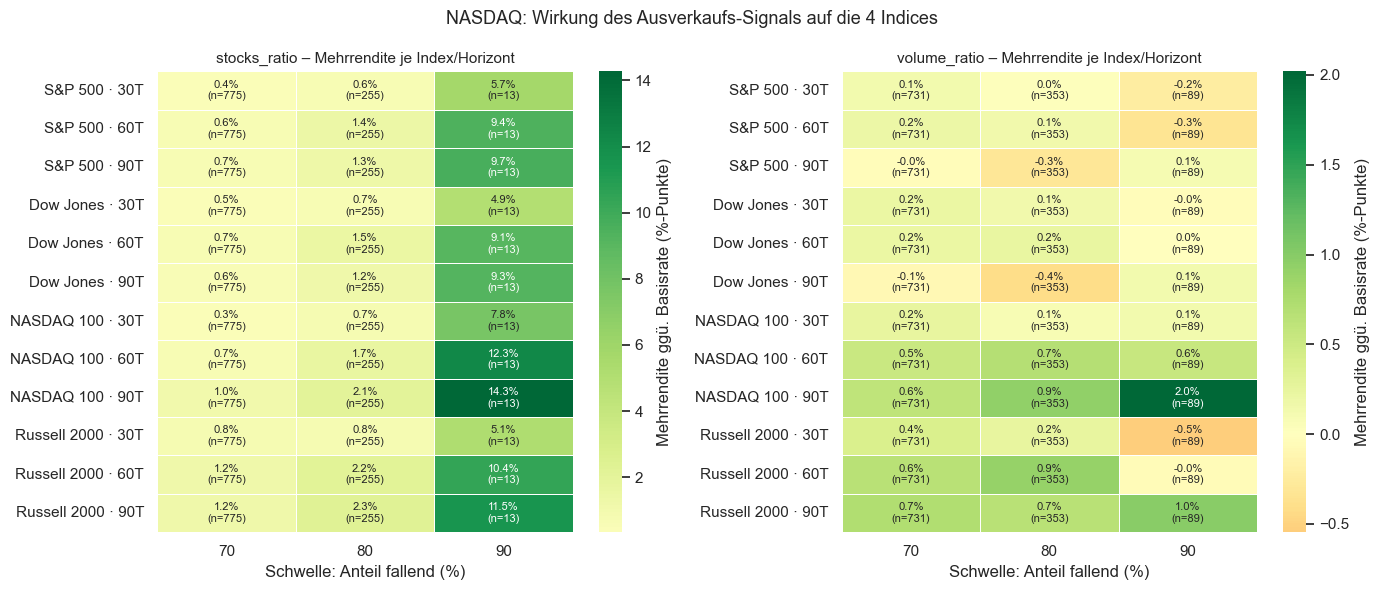

In [8]:
fig, achsen = plt.subplots(1, 2, figsize=(14, 6))
for achse, ratio in zip(achsen, ["stocks_ratio", "volume_ratio"]):
    teil = ad_teil[ad_teil["Ratio_Art"] == ratio].copy()
    teil["Zeile"] = teil["Index"] + " · " + teil["horizont_tage"].astype(str) + "T"
    pivot = teil.pivot(index="Zeile", columns="Niveau", values="Mehrrendite") * 100
    reihenfolge = [f"{ix} · {h}T" for ix in [c["name"] for c in INDICES.values()] for h in HORIZONS]
    pivot = pivot.reindex(reihenfolge)
    n_pivot = teil.pivot(index="Zeile", columns="Niveau", values="n_events").reindex(reihenfolge)
    annot = pivot.round(1).astype(str) + "%\n(n=" + n_pivot.astype(int).astype(str) + ")"
    sns.heatmap(pivot, ax=achse, cmap="RdYlGn", center=0, annot=annot, fmt="",
                annot_kws={"fontsize": 8}, linewidths=0.6, linecolor="white",
                cbar_kws={"label": "Mehrrendite ggü. Basisrate (%-Punkte)"})
    achse.set_title(f"{ratio} – Mehrrendite je Index/Horizont", fontsize=11)
    achse.set_xlabel("Schwelle: Anteil fallend (%)")
    achse.set_ylabel("")
fig.suptitle(f"NASDAQ: Wirkung des Ausverkaufs-Signals auf die 4 Indices", fontsize=13)
fig.tight_layout()
plt.show()

**Wie liest man die Heatmap?** Jede Zelle ist eine Kombination aus Index und
Horizont (Zeile) und Schwelle (Spalte). **Grün = Mehrrendite** (Signal besser als
der Durchschnitt), **Rot = Minderrendite**. In Klammern steht die Zahl der
Signaltage. Für die Praxis zeigt das auf einen Blick, in welchem Index und bei
welcher Schwelle sich ein extremer Ausverkauf am ehesten als Kaufgelegenheit
erwiesen hätte — und wo die Datenbasis zu dünn für eine verlässliche Aussage
ist.

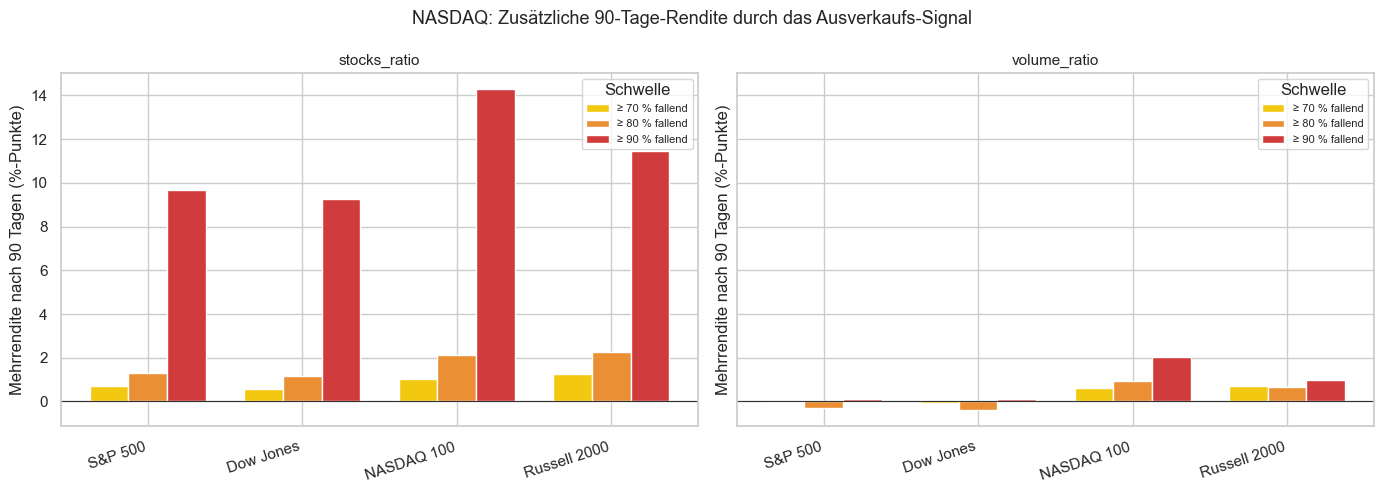

In [9]:
H_PLOT = 90
fig, achsen = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for achse, ratio in zip(achsen, ["stocks_ratio", "volume_ratio"]):
    teil = ad_teil[(ad_teil["Ratio_Art"] == ratio) & (ad_teil["horizont_tage"] == H_PLOT)]
    namen = [c["name"] for c in INDICES.values()]
    x = np.arange(len(namen))
    breite_bar = 0.25
    for i, niv in enumerate(AD_NIVEAUS):
        werte = [teil[(teil["Index"] == ix) & (teil["Niveau"] == niv)]["Mehrrendite"].values[0] * 100
                 for ix in namen]
        achse.bar(x + (i - 1) * breite_bar, werte, breite_bar, label=f"≥ {niv} % fallend",
                  color=["#f2c811", "#eb8f34", "#d03b3b"][i])
    achse.axhline(0, color="#333", linewidth=0.8)
    achse.set_xticks(x)
    achse.set_xticklabels(namen, rotation=18, ha="right")
    achse.set_title(f"{ratio}", fontsize=11)
    achse.set_ylabel(f"Mehrrendite nach {H_PLOT} Tagen (%-Punkte)")
    achse.legend(title="Schwelle", fontsize=8)
fig.suptitle(f"NASDAQ: Zusätzliche {H_PLOT}-Tage-Rendite durch das Ausverkaufs-Signal", fontsize=13)
fig.tight_layout()
plt.show()

**Wie liest man das?** Balken über null bedeuten: Der Einstieg nach dem
Signal hätte über 90 Tage mehr Rendite gebracht als ein beliebiger Tag. In der
Praxis heißt ein hoher Balken bei einer strengeren Schwelle (rot, ≥ 90 % fallend):
Je extremer der Ausverkauf, desto stärker die anschließende Erholung — allerdings
bei weniger Signaltagen (siehe Heatmap), also seltener nutzbar.

C:\Users\ramos\AppData\Local\Temp\ipykernel_34648\2769108008.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = achse.boxplot(daten, labels=["alle Tage", f"Signal ≥{NIVEAU_BOX}% fallend"],
C:\Users\ramos\AppData\Local\Temp\ipykernel_34648\2769108008.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = achse.boxplot(daten, labels=["alle Tage", f"Signal ≥{NIVEAU_BOX}% fallend"],
C:\Users\ramos\AppData\Local\Temp\ipykernel_34648\2769108008.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = achse.boxplot(daten, labels=["alle Tage", f"Signal ≥{NIVEAU_BOX}% fallend"],
C:\Users\ramos\AppData\Local\Temp\ipyker

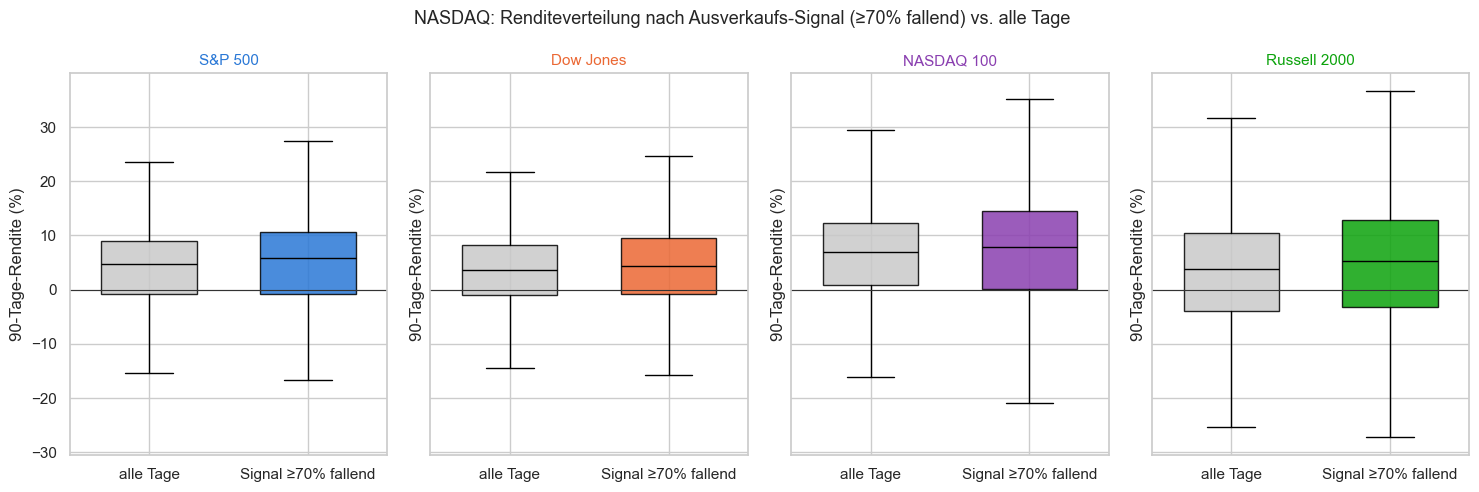

In [10]:
RATIO_BOX, NIVEAU_BOX, H_BOX = "stocks_ratio", 70, 90
namen_liste = list(INDICES.keys())
fig, achsen = plt.subplots(1, 4, figsize=(15, 5), sharey=True)
for achse, idx_key in zip(achsen, namen_liste):
    df = index_daten[idx_key]
    signal = ad_daten["NASDAQ"][RATIO_BOX].reindex(df.index) <= (100 - NIVEAU_BOX)
    daten = [df[f"fwd_return_{H_BOX}d"].dropna() * 100,
             df.loc[signal.reindex(df.index).fillna(False), f"fwd_return_{H_BOX}d"].dropna() * 100]
    bp = achse.boxplot(daten, labels=["alle Tage", f"Signal ≥{NIVEAU_BOX}% fallend"],
                       patch_artist=True, widths=0.6, showfliers=False)
    for patch, farbe in zip(bp["boxes"], ["#c9c9c9", INDEX_FARBEN[idx_key]]):
        patch.set_facecolor(farbe)
        patch.set_alpha(0.85)
    for med in bp["medians"]:
        med.set_color("black")
    achse.axhline(0, color="#333", linewidth=0.8)
    achse.set_title(INDICES[idx_key]["name"], fontsize=11, color=INDEX_FARBEN[idx_key])
    achse.set_ylabel(f"{H_BOX}-Tage-Rendite (%)")
fig.suptitle(f"NASDAQ: Renditeverteilung nach Ausverkaufs-Signal (≥{NIVEAU_BOX}% fallend) vs. alle Tage", fontsize=13)
fig.tight_layout()
plt.show()

**Wie liest man Boxplots?** Die Box zeigt die mittleren 50 % der Renditen,
der Strich in der Box den Median. Liegt die Signal-Box höher als die
„alle Tage"-Box, war das Signal im Schnitt besser. Für die Praxis wichtig: Ein
höherer Mittelwert nützt wenig, wenn die Streuung riesig ist — bei einem
Kapitulationssignal ist das nicht unüblich, da sich starke Ausverkäufe nicht
immer sofort erholen.

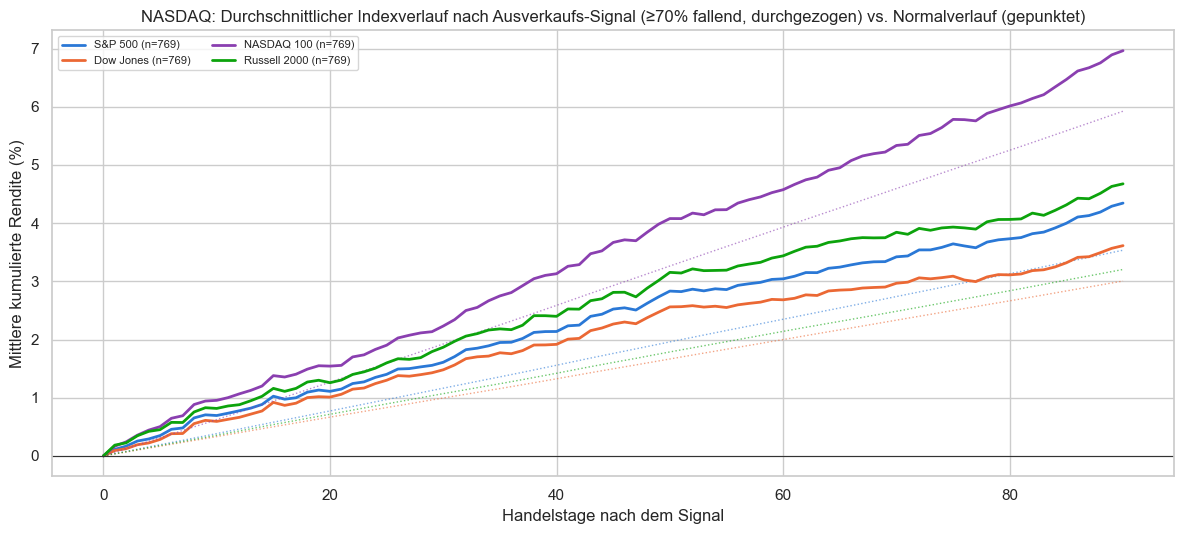

In [11]:
RATIO_EV, NIVEAU_EV, TAGE_EV = "stocks_ratio", 70, 90
fig, achse = plt.subplots(figsize=(12, 5.5))
for idx_key in namen_liste:
    df = index_daten[idx_key]
    close = df["Close"].values
    signal_reihe = (ad_daten["NASDAQ"][RATIO_EV].reindex(df.index) <= (100 - NIVEAU_EV)).fillna(False)
    signal_idx = np.where(signal_reihe.values)[0]
    pfade = [close[i:i + TAGE_EV + 1] / close[i] - 1
             for i in signal_idx if i + TAGE_EV < len(close)]
    if pfade:
        mittel = np.mean(pfade, axis=0) * 100
        achse.plot(range(TAGE_EV + 1), mittel, color=INDEX_FARBEN[idx_key], linewidth=2,
                   label=f"{INDICES[idx_key]['name']} (n={len(pfade)})")
    basis = [close[i:i + TAGE_EV + 1] / close[i] - 1 for i in range(len(close) - TAGE_EV)]
    achse.plot(range(TAGE_EV + 1), np.mean(basis, axis=0) * 100,
               color=INDEX_FARBEN[idx_key], linewidth=1, linestyle=":", alpha=0.6)
achse.axhline(0, color="#333", linewidth=0.8)
achse.set_xlabel("Handelstage nach dem Signal")
achse.set_ylabel("Mittlere kumulierte Rendite (%)")
achse.set_title(f"NASDAQ: Durchschnittlicher Indexverlauf nach Ausverkaufs-Signal "
                f"(≥{NIVEAU_EV}% fallend, durchgezogen) vs. Normalverlauf (gepunktet)")
achse.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

**Wie liest man die Event-Study?** Jede durchgezogene Linie ist der
gemittelte Kursverlauf in den 90 Tagen nach einem Ausverkaufs-Signal (Start =
0 %); die gepunktete Linie derselben Farbe ist der Normalverlauf des Index. Liegt
die durchgezogene Linie über der gepunkteten, hat sich der Index nach dem Signal
überdurchschnittlich entwickelt. Für die Praxis zeigt das nicht nur *ob*, sondern
**ab wann** ein möglicher Erholungseffekt einsetzt — wichtig für die Frage, wie
lange man eine Position nach einem solchen Signal halten sollte.

In [12]:
bel = ad_teil[ad_teil["belastbar"]].copy()
positiv = bel[bel["Mehrrendite"] > 0]
anteil_positiv = len(positiv) / len(bel) if len(bel) else float("nan")
signifikant = bel[(bel["Mehrrendite"] > 0) & bel["signifikant_5pct"]]

print(f"Börsenplatz NASDAQ — belastbare Kombinationen: {len(bel)} von {len(ad_teil)}")
print(f"  davon mit positiver Mehrrendite: {len(positiv)} ({anteil_positiv:.0%})")
print(f"  davon zusätzlich statistisch signifikant (p<0,05): {len(signifikant)}")
print()
print("Stärkste belastbare Signale (nach Mehrrendite):")
top = bel.sort_values("Mehrrendite", ascending=False).head(5)
for _, r in top.iterrows():
    stern = "*" if r["signifikant_5pct"] else " "
    print(f"  {stern} {r['Index']:<14s} | {r['Ratio_Art']:<12s} ≥{r['Niveau']}% fallend | {r['horizont_tage']}T: "
          f"{r['Mehrrendite']:+.1%} (Signal {r['mean_return']:+.1%} vs. Basis {r['mean_return_basis']:+.1%}, "
          f"Sharpe {r['sharpe']:.2f}, n={r['n_events']})")
print("\n  * = statistisch signifikant (p<0,05)")

Börsenplatz NASDAQ — belastbare Kombinationen: 60 von 72
  davon mit positiver Mehrrendite: 51 (85%)
  davon zusätzlich statistisch signifikant (p<0,05): 12

Stärkste belastbare Signale (nach Mehrrendite):
  * Russell 2000   | stocks_ratio ≥80% fallend | 90T: +2.3% (Signal +5.7% vs. Basis +3.4%, Sharpe 0.61, n=255)
  * Russell 2000   | stocks_ratio ≥80% fallend | 60T: +2.2% (Signal +4.4% vs. Basis +2.3%, Sharpe 0.70, n=255)
  * NASDAQ 100     | stocks_ratio ≥80% fallend | 90T: +2.1% (Signal +8.0% vs. Basis +5.9%, Sharpe 0.91, n=255)
    NASDAQ 100     | volume_ratio ≥90% fallend | 90T: +2.0% (Signal +7.9% vs. Basis +5.9%, Sharpe 0.89, n=89)
  * NASDAQ 100     | stocks_ratio ≥80% fallend | 60T: +1.7% (Signal +5.6% vs. Basis +3.9%, Sharpe 0.96, n=255)

  * = statistisch signifikant (p<0,05)


**Kernbefund für NASDAQ (dynamisch aus den Zahlen oben).** Als Faustregel
gilt: Ein extremer, breiter Ausverkauf am Börsenplatz NASDAQ ist dann ein
brauchbares Einstiegssignal, wenn die Mehrrendite über mehrere Indices, Niveaus
und Horizonte hinweg positiv ist. Einzeltreffer bei seltenen 90-%-Signalen
(kleines n) sollten vorsichtig interpretiert werden — es handelt sich um eine
explorative Auswertung historischer Durchschnitte ohne Transaktionskosten, und
überlappende Zeitfenster machen die p-Werte zu Orientierungswerten, keine
Handelsgarantie.

### 3.2 Börsenplatz NYSE

In [13]:
ad_teil = ad_niveau_tabelle[ad_niveau_tabelle["Börse"] == "NYSE"].copy()
anzeige = ad_teil.copy()
for spalte in ["mean_return", "mean_return_basis", "Mehrrendite", "mean_mdd"]:
    anzeige[spalte] = anzeige[spalte].map(lambda x: f"{x:+.1%}" if pd.notna(x) else "—")
anzeige["sharpe"] = anzeige["sharpe"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
anzeige["belastbar"] = anzeige["belastbar"].map(lambda x: "ja" if x else "nein")
display(anzeige[["Index", "Ratio_Art", "Niveau", "horizont_tage", "n_events",
                  "mean_return", "mean_return_basis", "Mehrrendite", "sharpe",
                  "signifikant_5pct", "belastbar"]])

,Index,Ratio_Art,Niveau,horizont_tage,n_events,mean_return,mean_return_basis,Mehrrendite,sharpe,signifikant_5pct,belastbar
72,S&P 500,stocks_ratio,70,30,894,+1.8%,+1.4%,+0.4%,0.78,False,ja
73,S&P 500,stocks_ratio,70,60,894,+3.5%,+2.8%,+0.7%,0.86,True,ja
74,S&P 500,stocks_ratio,70,90,894,+5.4%,+4.4%,+1.0%,0.91,True,ja
75,Dow Jones,stocks_ratio,70,30,894,+1.6%,+1.2%,+0.4%,0.75,True,ja
76,Dow Jones,stocks_ratio,70,60,894,+3.0%,+2.4%,+0.6%,0.81,True,ja
...,...,...,...,...,...,...,...,...,...,...,...
139,NASDAQ 100,volume_ratio,90,60,97,+7.0%,+4.4%,+2.6%,1.19,True,ja
140,NASDAQ 100,volume_ratio,90,90,97,+11.2%,+6.7%,+4.5%,1.35,True,ja
141,Russell 2000,volume_ratio,90,30,97,+1.4%,+1.3%,+0.1%,0.34,False,ja
142,Russell 2000,volume_ratio,90,60,97,+4.9%,+2.6%,+2.3%,0.73,False,ja


**Wie liest man die Tabelle?** Positive **Mehrrendite** heißt: Nach dem
Ausverkaufs-Signal lief der Index besser als im Durchschnitt — ein Hinweis
darauf, dass sich das überdehnte Gummiband tatsächlich löst. `signifikant_5pct`
zeigt an, ob dieser Unterschied statistisch abgesichert ist (t-Test und
Mann-Whitney-U-Test bestehen beide); `belastbar` warnt bei zu wenigen
Signaltagen, vor allem beim seltenen 90-%-Niveau.

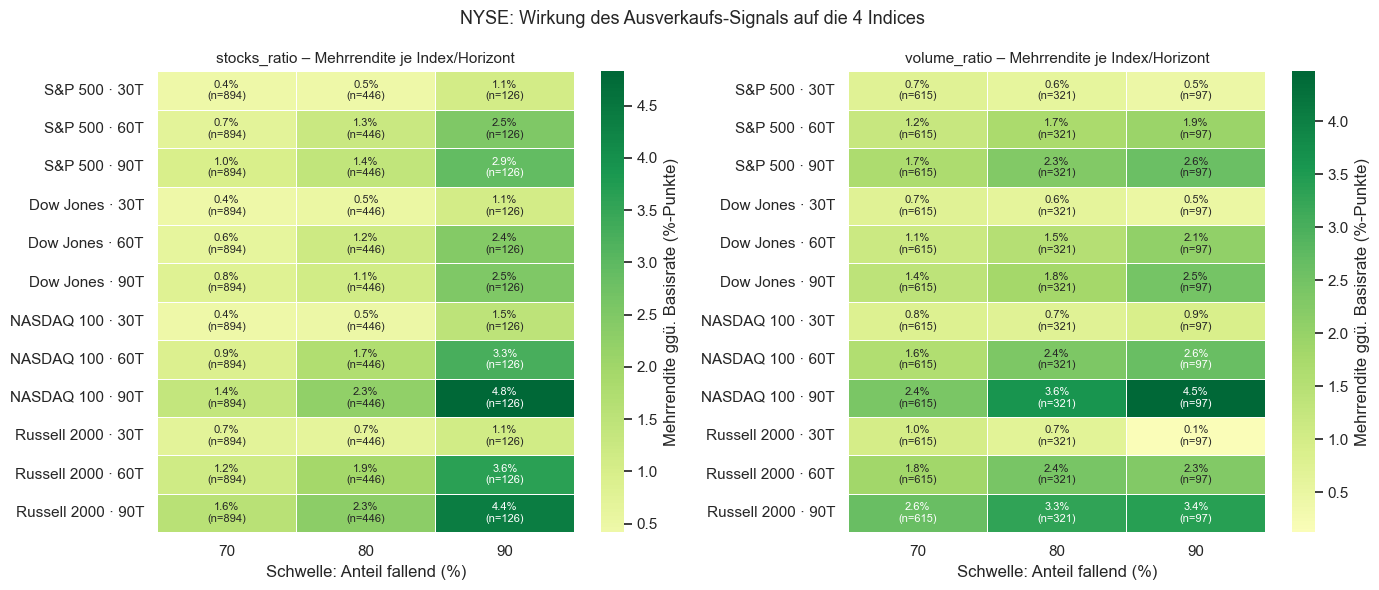

In [14]:
fig, achsen = plt.subplots(1, 2, figsize=(14, 6))
for achse, ratio in zip(achsen, ["stocks_ratio", "volume_ratio"]):
    teil = ad_teil[ad_teil["Ratio_Art"] == ratio].copy()
    teil["Zeile"] = teil["Index"] + " · " + teil["horizont_tage"].astype(str) + "T"
    pivot = teil.pivot(index="Zeile", columns="Niveau", values="Mehrrendite") * 100
    reihenfolge = [f"{ix} · {h}T" for ix in [c["name"] for c in INDICES.values()] for h in HORIZONS]
    pivot = pivot.reindex(reihenfolge)
    n_pivot = teil.pivot(index="Zeile", columns="Niveau", values="n_events").reindex(reihenfolge)
    annot = pivot.round(1).astype(str) + "%\n(n=" + n_pivot.astype(int).astype(str) + ")"
    sns.heatmap(pivot, ax=achse, cmap="RdYlGn", center=0, annot=annot, fmt="",
                annot_kws={"fontsize": 8}, linewidths=0.6, linecolor="white",
                cbar_kws={"label": "Mehrrendite ggü. Basisrate (%-Punkte)"})
    achse.set_title(f"{ratio} – Mehrrendite je Index/Horizont", fontsize=11)
    achse.set_xlabel("Schwelle: Anteil fallend (%)")
    achse.set_ylabel("")
fig.suptitle(f"NYSE: Wirkung des Ausverkaufs-Signals auf die 4 Indices", fontsize=13)
fig.tight_layout()
plt.show()

**Wie liest man die Heatmap?** Jede Zelle ist eine Kombination aus Index und
Horizont (Zeile) und Schwelle (Spalte). **Grün = Mehrrendite** (Signal besser als
der Durchschnitt), **Rot = Minderrendite**. In Klammern steht die Zahl der
Signaltage. Für die Praxis zeigt das auf einen Blick, in welchem Index und bei
welcher Schwelle sich ein extremer Ausverkauf am ehesten als Kaufgelegenheit
erwiesen hätte — und wo die Datenbasis zu dünn für eine verlässliche Aussage
ist.

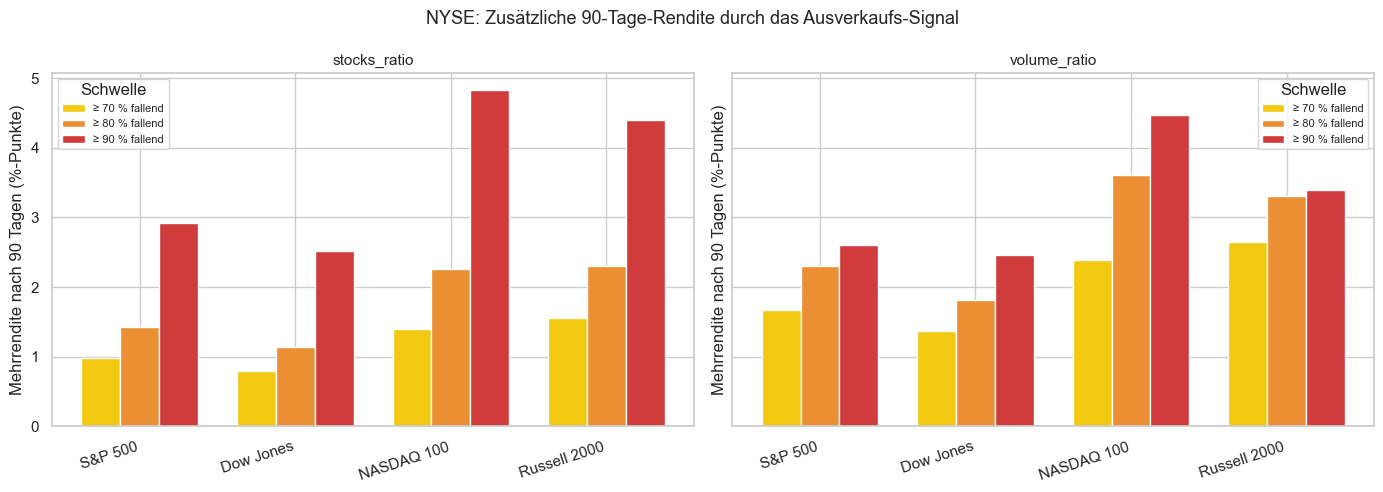

In [15]:
H_PLOT = 90
fig, achsen = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for achse, ratio in zip(achsen, ["stocks_ratio", "volume_ratio"]):
    teil = ad_teil[(ad_teil["Ratio_Art"] == ratio) & (ad_teil["horizont_tage"] == H_PLOT)]
    namen = [c["name"] for c in INDICES.values()]
    x = np.arange(len(namen))
    breite_bar = 0.25
    for i, niv in enumerate(AD_NIVEAUS):
        werte = [teil[(teil["Index"] == ix) & (teil["Niveau"] == niv)]["Mehrrendite"].values[0] * 100
                 for ix in namen]
        achse.bar(x + (i - 1) * breite_bar, werte, breite_bar, label=f"≥ {niv} % fallend",
                  color=["#f2c811", "#eb8f34", "#d03b3b"][i])
    achse.axhline(0, color="#333", linewidth=0.8)
    achse.set_xticks(x)
    achse.set_xticklabels(namen, rotation=18, ha="right")
    achse.set_title(f"{ratio}", fontsize=11)
    achse.set_ylabel(f"Mehrrendite nach {H_PLOT} Tagen (%-Punkte)")
    achse.legend(title="Schwelle", fontsize=8)
fig.suptitle(f"NYSE: Zusätzliche {H_PLOT}-Tage-Rendite durch das Ausverkaufs-Signal", fontsize=13)
fig.tight_layout()
plt.show()

**Wie liest man das?** Balken über null bedeuten: Der Einstieg nach dem
Signal hätte über 90 Tage mehr Rendite gebracht als ein beliebiger Tag. In der
Praxis heißt ein hoher Balken bei einer strengeren Schwelle (rot, ≥ 90 % fallend):
Je extremer der Ausverkauf, desto stärker die anschließende Erholung — allerdings
bei weniger Signaltagen (siehe Heatmap), also seltener nutzbar.

C:\Users\ramos\AppData\Local\Temp\ipykernel_34648\2182046543.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = achse.boxplot(daten, labels=["alle Tage", f"Signal ≥{NIVEAU_BOX}% fallend"],
C:\Users\ramos\AppData\Local\Temp\ipykernel_34648\2182046543.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = achse.boxplot(daten, labels=["alle Tage", f"Signal ≥{NIVEAU_BOX}% fallend"],
C:\Users\ramos\AppData\Local\Temp\ipykernel_34648\2182046543.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = achse.boxplot(daten, labels=["alle Tage", f"Signal ≥{NIVEAU_BOX}% fallend"],
C:\Users\ramos\AppData\Local\Temp\ipyker

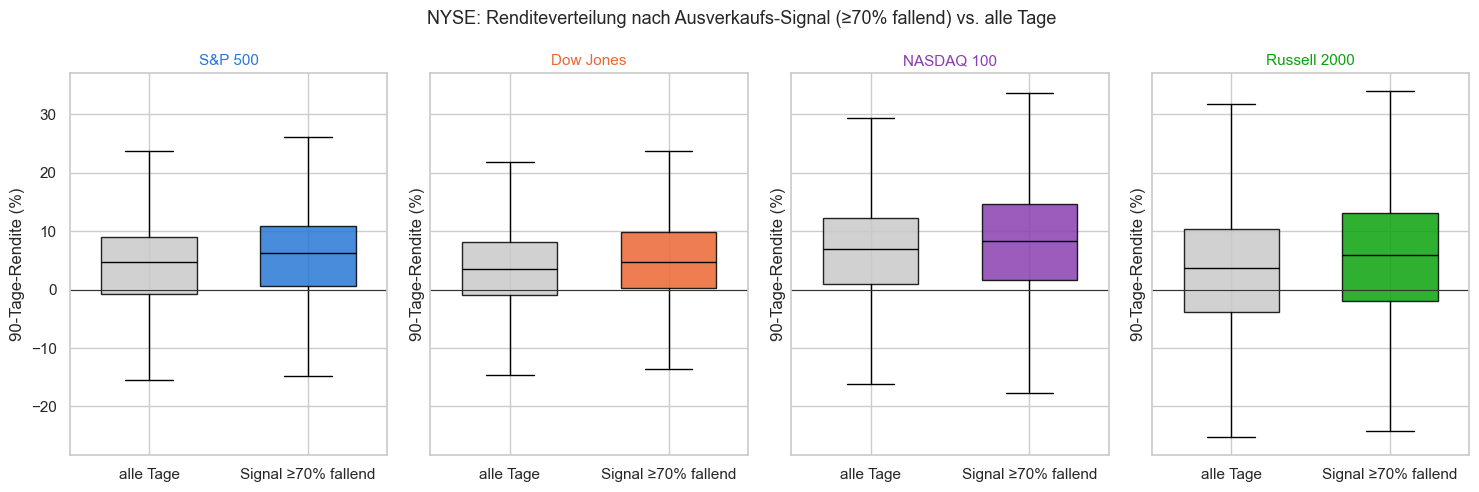

In [16]:
RATIO_BOX, NIVEAU_BOX, H_BOX = "stocks_ratio", 70, 90
namen_liste = list(INDICES.keys())
fig, achsen = plt.subplots(1, 4, figsize=(15, 5), sharey=True)
for achse, idx_key in zip(achsen, namen_liste):
    df = index_daten[idx_key]
    signal = ad_daten["NYSE"][RATIO_BOX].reindex(df.index) <= (100 - NIVEAU_BOX)
    daten = [df[f"fwd_return_{H_BOX}d"].dropna() * 100,
             df.loc[signal.reindex(df.index).fillna(False), f"fwd_return_{H_BOX}d"].dropna() * 100]
    bp = achse.boxplot(daten, labels=["alle Tage", f"Signal ≥{NIVEAU_BOX}% fallend"],
                       patch_artist=True, widths=0.6, showfliers=False)
    for patch, farbe in zip(bp["boxes"], ["#c9c9c9", INDEX_FARBEN[idx_key]]):
        patch.set_facecolor(farbe)
        patch.set_alpha(0.85)
    for med in bp["medians"]:
        med.set_color("black")
    achse.axhline(0, color="#333", linewidth=0.8)
    achse.set_title(INDICES[idx_key]["name"], fontsize=11, color=INDEX_FARBEN[idx_key])
    achse.set_ylabel(f"{H_BOX}-Tage-Rendite (%)")
fig.suptitle(f"NYSE: Renditeverteilung nach Ausverkaufs-Signal (≥{NIVEAU_BOX}% fallend) vs. alle Tage", fontsize=13)
fig.tight_layout()
plt.show()

**Wie liest man Boxplots?** Die Box zeigt die mittleren 50 % der Renditen,
der Strich in der Box den Median. Liegt die Signal-Box höher als die
„alle Tage"-Box, war das Signal im Schnitt besser. Für die Praxis wichtig: Ein
höherer Mittelwert nützt wenig, wenn die Streuung riesig ist — bei einem
Kapitulationssignal ist das nicht unüblich, da sich starke Ausverkäufe nicht
immer sofort erholen.

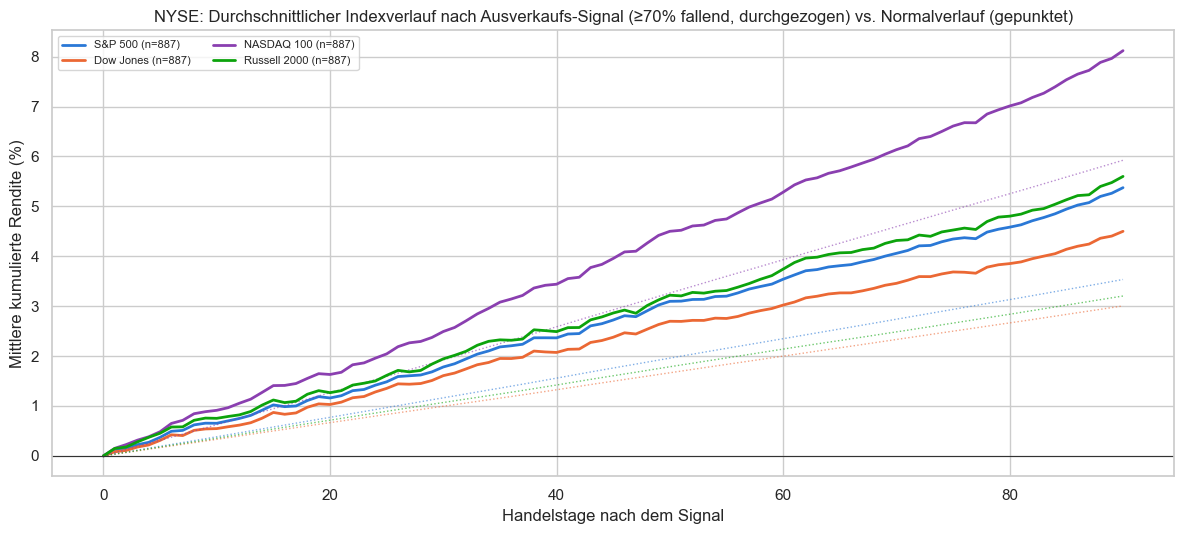

In [17]:
RATIO_EV, NIVEAU_EV, TAGE_EV = "stocks_ratio", 70, 90
fig, achse = plt.subplots(figsize=(12, 5.5))
for idx_key in namen_liste:
    df = index_daten[idx_key]
    close = df["Close"].values
    signal_reihe = (ad_daten["NYSE"][RATIO_EV].reindex(df.index) <= (100 - NIVEAU_EV)).fillna(False)
    signal_idx = np.where(signal_reihe.values)[0]
    pfade = [close[i:i + TAGE_EV + 1] / close[i] - 1
             for i in signal_idx if i + TAGE_EV < len(close)]
    if pfade:
        mittel = np.mean(pfade, axis=0) * 100
        achse.plot(range(TAGE_EV + 1), mittel, color=INDEX_FARBEN[idx_key], linewidth=2,
                   label=f"{INDICES[idx_key]['name']} (n={len(pfade)})")
    basis = [close[i:i + TAGE_EV + 1] / close[i] - 1 for i in range(len(close) - TAGE_EV)]
    achse.plot(range(TAGE_EV + 1), np.mean(basis, axis=0) * 100,
               color=INDEX_FARBEN[idx_key], linewidth=1, linestyle=":", alpha=0.6)
achse.axhline(0, color="#333", linewidth=0.8)
achse.set_xlabel("Handelstage nach dem Signal")
achse.set_ylabel("Mittlere kumulierte Rendite (%)")
achse.set_title(f"NYSE: Durchschnittlicher Indexverlauf nach Ausverkaufs-Signal "
                f"(≥{NIVEAU_EV}% fallend, durchgezogen) vs. Normalverlauf (gepunktet)")
achse.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

**Wie liest man die Event-Study?** Jede durchgezogene Linie ist der
gemittelte Kursverlauf in den 90 Tagen nach einem Ausverkaufs-Signal (Start =
0 %); die gepunktete Linie derselben Farbe ist der Normalverlauf des Index. Liegt
die durchgezogene Linie über der gepunkteten, hat sich der Index nach dem Signal
überdurchschnittlich entwickelt. Für die Praxis zeigt das nicht nur *ob*, sondern
**ab wann** ein möglicher Erholungseffekt einsetzt — wichtig für die Frage, wie
lange man eine Position nach einem solchen Signal halten sollte.

In [18]:
bel = ad_teil[ad_teil["belastbar"]].copy()
positiv = bel[bel["Mehrrendite"] > 0]
anteil_positiv = len(positiv) / len(bel) if len(bel) else float("nan")
signifikant = bel[(bel["Mehrrendite"] > 0) & bel["signifikant_5pct"]]

print(f"Börsenplatz NYSE — belastbare Kombinationen: {len(bel)} von {len(ad_teil)}")
print(f"  davon mit positiver Mehrrendite: {len(positiv)} ({anteil_positiv:.0%})")
print(f"  davon zusätzlich statistisch signifikant (p<0,05): {len(signifikant)}")
print()
print("Stärkste belastbare Signale (nach Mehrrendite):")
top = bel.sort_values("Mehrrendite", ascending=False).head(5)
for _, r in top.iterrows():
    stern = "*" if r["signifikant_5pct"] else " "
    print(f"  {stern} {r['Index']:<14s} | {r['Ratio_Art']:<12s} ≥{r['Niveau']}% fallend | {r['horizont_tage']}T: "
          f"{r['Mehrrendite']:+.1%} (Signal {r['mean_return']:+.1%} vs. Basis {r['mean_return_basis']:+.1%}, "
          f"Sharpe {r['sharpe']:.2f}, n={r['n_events']})")
print("\n  * = statistisch signifikant (p<0,05)")

Börsenplatz NYSE — belastbare Kombinationen: 72 von 72
  davon mit positiver Mehrrendite: 72 (100%)
  davon zusätzlich statistisch signifikant (p<0,05): 52

Stärkste belastbare Signale (nach Mehrrendite):
  * NASDAQ 100     | stocks_ratio ≥90% fallend | 90T: +4.8% (Signal +11.6% vs. Basis +6.7%, Sharpe 1.31, n=126)
  * NASDAQ 100     | volume_ratio ≥90% fallend | 90T: +4.5% (Signal +11.2% vs. Basis +6.7%, Sharpe 1.35, n=97)
  * Russell 2000   | stocks_ratio ≥90% fallend | 90T: +4.4% (Signal +8.4% vs. Basis +4.0%, Sharpe 0.84, n=126)
  * Russell 2000   | stocks_ratio ≥90% fallend | 60T: +3.6% (Signal +6.2% vs. Basis +2.6%, Sharpe 0.87, n=126)
  * NASDAQ 100     | volume_ratio ≥80% fallend | 90T: +3.6% (Signal +10.3% vs. Basis +6.7%, Sharpe 1.38, n=321)

  * = statistisch signifikant (p<0,05)


**Kernbefund für NYSE (dynamisch aus den Zahlen oben).** Als Faustregel
gilt: Ein extremer, breiter Ausverkauf am Börsenplatz NYSE ist dann ein
brauchbares Einstiegssignal, wenn die Mehrrendite über mehrere Indices, Niveaus
und Horizonte hinweg positiv ist. Einzeltreffer bei seltenen 90-%-Signalen
(kleines n) sollten vorsichtig interpretiert werden — es handelt sich um eine
explorative Auswertung historischer Durchschnitte ohne Transaktionskosten, und
überlappende Zeitfenster machen die p-Werte zu Orientierungswerten, keine
Handelsgarantie.

### 3.3 Feste Einstiegs-Schwelle für die Strategie-Vergleiche in Abschnitt 5

Für die Strategie-Vergleiche in Abschnitt 5 wird bewusst **eine feste Schwelle**
verwendet (70 % fallend, `AD_SCHWELLE_KOMBI`) statt je Index der jeweils
stärksten Schwelle aus der Kreuzauswertung oben — sonst würde für jeden Index
im Nachhinein die individuell beste Variante herausgesucht, was die
Aussagekraft der Strategie-Vergleiche verzerren würde (dasselbe Prinzip wie bei
der Ampel-Kombination: eine einheitliche, nicht nachträglich optimierte Regel
überzeugt durch Robustheit, nicht durch Bestpassung auf die Vergangenheit).

In [19]:
ad_signal_alle_indices: dict[str, pd.Series] = {}
for idx_key, df in index_daten.items():
    sig_nasdaq = (ad_daten["NASDAQ"]["stocks_ratio"] <= (100 - AD_SCHWELLE_KOMBI)) | \
                 (ad_daten["NASDAQ"]["volume_ratio"] <= (100 - AD_SCHWELLE_KOMBI))
    sig_nyse = (ad_daten["NYSE"]["stocks_ratio"] <= (100 - AD_SCHWELLE_KOMBI)) | \
               (ad_daten["NYSE"]["volume_ratio"] <= (100 - AD_SCHWELLE_KOMBI))
    sig_nasdaq = sig_nasdaq.reindex(df.index).fillna(False)
    sig_nyse = sig_nyse.reindex(df.index).fillna(False)
    ad_signal_alle_indices[idx_key] = sig_nasdaq | sig_nyse
    print(f"{INDICES[idx_key]['name']}: {int(ad_signal_alle_indices[idx_key].sum()):,} Signaltage "
          f"({ad_signal_alle_indices[idx_key].mean():.1%} aller Handelstage)")

S&P 500: 1,147 Signaltage (23.3% aller Handelstage)
Dow Jones: 1,147 Signaltage (23.3% aller Handelstage)
NASDAQ 100: 1,147 Signaltage (23.3% aller Handelstage)
Russell 2000: 1,147 Signaltage (23.3% aller Handelstage)


**Was wurde hier gemacht?** Für jeden Index eine einzige A/D-Signalmaske
gebildet: ein Tag zählt als Signaltag, wenn an NASDAQ **oder** NYSE der Anteil
fallender Aktien **oder** fallenden Volumens mindestens 70 % erreicht. Diese
Maske wird in Abschnitt 5 zusammen mit den Mustern aus Abschnitt 4 für die
kombinierten Strategien verwendet.

## 4. Isolierte Einzelbewertung der übrigen Einstiegssignale (alle 4 Indices)

Dieser Abschnitt beantwortet Blickwinkel 1 aus der Einleitung für die übrigen
elf Muster der Einstiegssignale-Tabelle (gleitende Durchschnitte, Marktbreite,
Put/Call-Ratio): Wie wirkt jedes Signal für sich genommen, ganz ohne Bezug zur
Risikoampel? In der Tabellenspalte "Index" ist bei diesen Einträgen durchgängig
"SPX" (S&P 500) vermerkt — das bezieht sich auf den Index, an dem das jeweilige
Muster ursprünglich beschrieben wurde, **nicht** auf eine inhaltliche
Beschränkung: Die Regel hinter jedem Signal (z. B. "RSI14 unter 30" oder
"Put/Call-Ratio im obersten Zehntel") ist eine allgemeine technische Definition,
die sich unverändert auf die Kursreihe jedes beliebigen Index anwenden lässt.
Alle elf Muster werden daher hier für **alle vier Indices** ausgewertet.

Eine Datenquelle ist dabei nicht indexspezifisch, sondern für den gesamten
US-Aktienmarkt einheitlich: die **Put/Call-Ratio** (Verhältnis gehandelter
Verkaufs- zu Kaufoptionen auf Einzelaktien, "Equity"). Diese eine gemeinsame
Zeitreihe wird unten mit den Kursdaten jedes der vier Indices verknüpft — es ist
also derselbe Marktstimmungs-Indikator, nur gegen vier unterschiedliche
Kurshistorien ausgewertet.

In [20]:
df_erweitert: dict[str, pd.DataFrame] = {}
event_masken: dict[str, dict[str, pd.Series]] = {idx_key: {} for idx_key in INDICES}
alle_signal_tabellen: list[pd.DataFrame] = []

pcr_roh = lade_pcr(PCR_FILE, "Equity")
for fenster in PCR_MA_FENSTER:
    pcr_roh[f"Equity_ma{fenster}"] = pcr_roh["Equity_close"].rolling(fenster, min_periods=fenster).mean()

for idx_key, df in index_daten.items():
    df = df.copy()
    # Wöchentlicher SMA20 (für H4/D1) sowie RSI14 (für H6) ergänzen.
    wochenschluss = df["Close"].resample("W-FRI").last().dropna()
    sma20_w = wochenschluss.rolling(20, min_periods=20).mean().rename("SMA20_w")
    mapping = pd.merge_asof(df.reset_index()[["Date"]], sma20_w.reset_index(), on="Date", direction="backward")
    df["SMA20_w"] = mapping["SMA20_w"].values
    df["RSI14"] = berechne_rsi(df["Close"], 14)

    # Put/Call-Ratio (marktweit, nicht indexspezifisch) mit dem Index-Datensatz verknüpfen.
    df = df.join(pcr_roh, how="inner")
    df_erweitert[idx_key] = df

for idx_key, df in df_erweitert.items():
    print(f"{INDICES[idx_key]['name']} mit PCR verbunden: {len(df):,} Handelstage "
          f"({df.index.min().date()} bis {df.index.max().date()})")


def zeige_90_tage(signal_name: str) -> None:
    '''Zeigt kompakt den 90-Tage-Horizont eines Signals für alle 4 Indices
    (die vollständigen 30/60/90-Tage-Ergebnisse stehen in alle_signal_tabellen
    bzw. im Export, Abschnitt 6).'''
    teil = pd.concat(
        [t for t in alle_signal_tabellen if (t["signal"] == signal_name).all()], ignore_index=True
    )
    display(teil[teil["horizont_tage"] == 90][
        ["Index", "n_events", "mean_return", "mean_mdd", "sharpe", "signifikant_5pct"]
    ])

S&P 500 mit PCR verbunden: 4,917 Handelstage (2007-01-23 bis 2026-08-11)
Dow Jones mit PCR verbunden: 4,917 Handelstage (2007-01-23 bis 2026-08-11)
NASDAQ 100 mit PCR verbunden: 4,917 Handelstage (2007-01-23 bis 2026-08-11)
Russell 2000 mit PCR verbunden: 4,917 Handelstage (2007-01-23 bis 2026-08-11)


**Was wurde hier gemacht?** Für jeden Index eine erweiterte Kopie seiner
Kursdaten angelegt, ergänzt um einen wöchentlichen SMA20 (für Muster H4), den
RSI14-Indikator (für Muster H6) und die gemeinsame Put/Call-Ratio-Zeitreihe. Dazu
zwei leere Speicher: `event_masken` sammelt später je Index und Signal, an welchen
Tagen das jeweilige Signal ausgelöst hat (wird in Abschnitt 5 gebraucht),
`alle_signal_tabellen` sammelt die Kennzahlen-Tabellen aller Muster und Indices
für die zusammenfassende Übersicht (4.11) und den Export (Abschnitt 6). Die
Hilfsfunktion `zeige_90_tage` erspart es, den Anzeige-Code für jedes der elf
Muster elfmal zu wiederholen.

### 4.1 SMA H4 — D1-Muster (Tages-SMA20 dreht nach ≥5 Tagen Rückgang, Wochen-SMA20 steigt)

In [21]:
for idx_key, df in df_erweitert.items():
    rueckgangs_laenge_d = konsekutive_rueckgangs_laenge(df["SMA20_d"]).shift(1)
    tages_sma_dreht_wieder = df["SMA20_d"].diff() > 0
    wochen_sma_steigt = df["SMA20_w"].diff() > 0
    event = tages_sma_dreht_wieder & (rueckgangs_laenge_d >= 5) & wochen_sma_steigt
    event_masken[idx_key]["H4_D1"] = event
    tabelle = event_kennzahlen(df, event, "H4_D1")
    tabelle["Index"] = INDICES[idx_key]["name"]
    alle_signal_tabellen.append(tabelle)

zeige_90_tage("H4_D1")

,Index,n_events,mean_return,mean_mdd,sharpe,signifikant_5pct
2,S&P 500,12,0.0398,-0.0594,1.2007,False
5,Dow Jones,15,0.0156,-0.0840,0.5062,False
8,NASDAQ 100,9,0.0409,-0.0987,0.4977,False
11,Russell 2000,6,-0.0604,-0.1897,-0.5176,False


**Was zeigt diese Tabelle und was bedeutet das für die Praxis?** Die Wirkung
des Signals "der tägliche SMA20 dreht nach mindestens fünf Tagen Rückgang wieder
nach oben, während der wöchentliche SMA20 weiter steigt" — je Index die Anzahl
der Auslöse-Tage (`n_events`), die durchschnittliche 90-Tage-Rendite und der
90-Tage-Drawdown danach, die Sharpe Ratio sowie ob der Renditeunterschied zur
Basisrate statistisch signifikant ist. Bei geringer Ereigniszahl (`n_events`) ist
das Ergebnis eher deskriptiv zu werten, da wenige Beobachtungen anfälliger für
Zufallseffekte sind — für die Praxis heißt das: ein hübsches Ergebnis, aber keine
verlässliche Handelsregel.

### 4.2 SMA H6 — RSI14 überverkauft (< 30) als Einstiegssignal

In [22]:
for idx_key, df in df_erweitert.items():
    event = df["RSI14"] < 30
    event_masken[idx_key]["H6_RSI_ueberverkauft"] = event
    tabelle = event_kennzahlen(df, event, "H6_RSI_ueberverkauft")
    tabelle["Index"] = INDICES[idx_key]["name"]
    alle_signal_tabellen.append(tabelle)

zeige_90_tage("H6_RSI_ueberverkauft")

,Index,n_events,mean_return,mean_mdd,sharpe,signifikant_5pct
2,S&P 500,88,0.0667,-0.1257,0.7005,False
5,Dow Jones,102,0.0671,-0.1103,0.8212,True
8,NASDAQ 100,55,0.0811,-0.1407,0.8358,False
11,Russell 2000,124,0.0891,-0.1530,0.9393,True


**Was zeigt diese Tabelle und was bedeutet das für die Praxis?** Die Wirkung
eines "überverkauften" RSI14 (unter 30) je Index — ein klassisches
Kontraindikator-Signal: Nach besonders schnellen, kurzfristigen Kursrückgängen
wird häufig eine Gegenbewegung erwartet. Für die Praxis relevant ist vor allem,
ob dieser Effekt über mehrere Indices hinweg signifikant und nicht nur ein
Zufallstreffer in einem einzelnen Markt ist.

### 4.3 SMA-Ampel-Systematik — Trendscore-Verbesserung

Der Trend-Score fasst zwei Kriterien in einer Zahl von 0 (bullisch) bis 2
(bärisch) zusammen: Steht der Kurs über seinem SMA200 und steigt der SMA200
gleichzeitig, ist der Score 0; sind beide Kriterien negativ, ist er 2; sonst 1. Ein
Einstiegssignal liegt vor, wenn sich dieser Wert gegenüber dem Vortag verbessert
(die Zahl sinkt).

In [23]:
for idx_key, df in df_erweitert.items():
    kurs_ueber_sma200 = df["Close"] > df["SMA200_d"]
    sma200_steigend = df["SMA200_d"].diff() > 0
    df["Trend_Score"] = trend_score(kurs_ueber_sma200, sma200_steigend)
    event = df["Trend_Score"].diff() < 0
    event_masken[idx_key]["Trendscore_Verbesserung"] = event
    tabelle = event_kennzahlen(df, event, "Trendscore_Verbesserung")
    tabelle["Index"] = INDICES[idx_key]["name"]
    alle_signal_tabellen.append(tabelle)

zeige_90_tage("Trendscore_Verbesserung")

,Index,n_events,mean_return,mean_mdd,sharpe,signifikant_5pct
2,S&P 500,100,0.0542,-0.0952,1.1482,False
5,Dow Jones,143,0.0537,-0.0805,1.2322,True
8,NASDAQ 100,118,0.0741,-0.1165,0.7259,False
11,Russell 2000,156,0.0241,-0.1234,0.2982,False


**Was zeigt diese Tabelle und was bedeutet das für die Praxis?** Die Wirkung
einer Verbesserung des Trend-Scores je Index — dieses Signal löst
vergleichsweise häufig aus (`n_events`), da schon der Wechsel von Stufe 2 auf 1
oder von 1 auf 0 zählt, nicht nur eine vollständige Trendwende. Für die Praxis
bedeutet die hohe Ereigniszahl: statistisch gut abgesichert, aber als alleiniges
Einstiegskriterium wenig selektiv.

### 4.4 Marktbreite B3 — unterstes Quartil (SMA200-Breite, Q1)

In [24]:
for idx_key, df in df_erweitert.items():
    df["Quartil_SMA200"] = breite_quartil(df, 200)
    event = df["Quartil_SMA200"] == QUARTIL_LABELS_BREITE[0]
    event_masken[idx_key]["B3_Q1_SMA200"] = event
    tabelle = event_kennzahlen(df, event, "B3_Q1_SMA200")
    tabelle["Index"] = INDICES[idx_key]["name"]
    alle_signal_tabellen.append(tabelle)

zeige_90_tage("B3_Q1_SMA200")

,Index,n_events,mean_return,mean_mdd,sharpe,signifikant_5pct
2,S&P 500,342,0.0847,-0.1437,0.9740,True
5,Dow Jones,352,0.0275,-0.1491,0.2962,False
8,NASDAQ 100,332,0.0914,-0.1520,0.9135,True
11,Russell 2000,220,0.1460,-0.1137,1.9141,True


**Was zeigt diese Tabelle und was bedeutet das für die Praxis?** Die Wirkung,
wenn die längerfristige Marktbreite (Anteil der Indexmitglieder über ihrem
SMA200) im untersten Viertel ihrer historischen Verteilung liegt — eine
besonders breite, lang anhaltende Schwäche. Für die Praxis ist das eher ein
Signal für eine strukturell angespannte Marktphase als für einen kurzfristigen
Einstiegszeitpunkt.

### 4.5 Marktbreite B5 — Frühindikator Erholung

In [25]:
for idx_key, df in df_erweitert.items():
    event = fruehindikator_erholung(df["breite_sma20"], df["breite_sma200"])
    event_masken[idx_key]["B5_Fruehindikator_Erholung"] = event
    tabelle = event_kennzahlen(df, event, "B5_Fruehindikator_Erholung")
    tabelle["Index"] = INDICES[idx_key]["name"]
    alle_signal_tabellen.append(tabelle)

zeige_90_tage("B5_Fruehindikator_Erholung")

,Index,n_events,mean_return,mean_mdd,sharpe,signifikant_5pct
2,S&P 500,33,0.0636,-0.1300,1.0514,False
5,Dow Jones,47,0.0040,-0.1491,0.0472,False
8,NASDAQ 100,30,0.0776,-0.1383,0.8269,False
11,Russell 2000,12,0.1318,-0.1059,2.1122,True


**Was zeigt diese Tabelle und was bedeutet das für die Praxis?** Die Wirkung
einer erkannten Erholungssequenz in der Marktbreite (vorherige deutliche
Schwäche, gefolgt von einem Anstieg der kurzfristigen Breite über 50 %) — dieses
Signal ist naturgemäß selten (kleine `n_events`), da es eine spezifische Abfolge
voraussetzt. Für die Praxis heißt das: interessant als Bestätigungssignal, aber
zu selten für eine regelmäßig nutzbare Strategie.

### 4.6 Marktbreite B9 — Breadth Collapse (Einbruch von ≥60 % auf ≤40 % binnen 10 Handelstagen)

In [26]:
THRUST_FENSTER, THRUST_UNTEN, THRUST_OBEN = 10, 40, 60
for w in BREADTH_WINDOWS:
    signalname = f"B9_Collapse_SMA{w}"
    for idx_key, df in df_erweitert.items():
        breite = df[f"breite_sma{w}"]
        maximum_vorher = breite.shift(1).rolling(window=THRUST_FENSTER, min_periods=THRUST_FENSTER).max()
        event = (breite <= THRUST_UNTEN) & (maximum_vorher >= THRUST_OBEN)
        event_masken[idx_key][signalname] = event
        tabelle = event_kennzahlen(df, event, signalname)
        tabelle["Index"] = INDICES[idx_key]["name"]
        alle_signal_tabellen.append(tabelle)
    zeige_90_tage(signalname)

,Index,n_events,mean_return,mean_mdd,sharpe,signifikant_5pct
2,S&P 500,666,0.0454,-0.1001,0.7708,True
5,Dow Jones,777,0.0427,-0.0874,0.9445,True
8,NASDAQ 100,660,0.0742,-0.1112,0.9969,True
11,Russell 2000,339,0.0351,-0.1167,0.6049,False


,Index,n_events,mean_return,mean_mdd,sharpe,signifikant_5pct
2,S&P 500,231,0.0573,-0.1040,0.9745,True
5,Dow Jones,404,0.0446,-0.0931,0.9330,True
8,NASDAQ 100,261,0.0778,-0.1175,0.9846,True
11,Russell 2000,98,0.0540,-0.1138,0.7996,False


,Index,n_events,mean_return,mean_mdd,sharpe,signifikant_5pct
2,S&P 500,31,0.1031,-0.1170,2.5957,True
5,Dow Jones,71,0.0708,-0.1026,1.4753,True
8,NASDAQ 100,31,0.1334,-0.1212,1.1801,False
11,Russell 2000,1,0.0669,-0.0799,NaN,False


**Was zeigt diese Tabelle und was bedeutet das für die Praxis?** Dieses Muster
wird für alle drei Marktbreite-Fenster (SMA20/50/200) einzeln geprüft: Ist die
Marktbreite innerhalb von 10 Handelstagen von mindestens 60 % auf höchstens 40 %
eingebrochen ("Breadth Collapse")? Ein plötzlicher, breiter Stimmungsumschwung
wird hier als mögliches Einstiegssignal gewertet — für die Praxis ist das nahe
verwandt mit dem Kapitulationssignal aus Abschnitt 3, nur auf Basis der
Marktbreite statt der Advancing/Declining-Zahlen.

### 4.7 Put/Call Ratio P1 — oberstes Dezil (Equity, Kontraindikator)

In [27]:
for idx_key, df in df_erweitert.items():
    oben, _unten = pcr_extremregime(df, "Equity")
    event = oben
    event_masken[idx_key]["P1_PCR_oberstes_Dezil"] = event
    tabelle = event_kennzahlen(df, event, "P1_PCR_oberstes_Dezil")
    tabelle["Index"] = INDICES[idx_key]["name"]
    alle_signal_tabellen.append(tabelle)

zeige_90_tage("P1_PCR_oberstes_Dezil")

,Index,n_events,mean_return,mean_mdd,sharpe,signifikant_5pct
2,S&P 500,489,0.0862,-0.0778,2.0757,True
5,Dow Jones,489,0.0769,-0.0731,1.9343,True
8,NASDAQ 100,489,0.1198,-0.0841,2.2812,True
11,Russell 2000,489,0.0990,-0.1073,1.8275,True


**Was zeigt diese Tabelle und was bedeutet das für die Praxis?** Die Wirkung
einer besonders hohen Put/Call-Ratio (oberste 10 % ihrer historischen
Verteilung) — viele Marktteilnehmer sichern sich gegen fallende Kurse ab oder
spekulieren darauf; historisch gilt ein Extremwert oft als Kontraindikator (viel
Angst am Markt fällt häufig mit Tiefpunkten zusammen). Für die Praxis ist dieses
Signal besonders interessant, weil es unabhängig von der Kursbewegung selbst ist
— es misst Marktstimmung, nicht Preis.

### 4.8 Put/Call Ratio P3 — oberstes Quartil (Equity, Kontraindikator)

In [28]:
for idx_key, df in df_erweitert.items():
    df["Quartil_PCR_Equity"] = pcr_quartil(df, "Equity")
    event = df["Quartil_PCR_Equity"] == QUARTIL_LABELS_PCR[3]
    event_masken[idx_key]["P3_PCR_Q4"] = event
    tabelle = event_kennzahlen(df, event, "P3_PCR_Q4")
    tabelle["Index"] = INDICES[idx_key]["name"]
    alle_signal_tabellen.append(tabelle)

zeige_90_tage("P3_PCR_Q4")

,Index,n_events,mean_return,mean_mdd,sharpe,signifikant_5pct
2,S&P 500,1222,0.0683,-0.0760,1.5253,True
5,Dow Jones,1222,0.0601,-0.0724,1.4456,True
8,NASDAQ 100,1222,0.1010,-0.0843,1.7972,True
11,Russell 2000,1222,0.0705,-0.1061,1.1906,True


**Was zeigt diese Tabelle und was bedeutet das für die Praxis?** Dieselbe Idee
wie 4.7, aber mit einer weniger strengen Schwelle (oberstes Viertel statt
oberstes Zehntel) — dadurch mehr Ereignisse (`n_events`), aber im Schnitt
vermutlich ein etwas schwächerer Effekt. Für die Praxis ist das der klassische
Zielkonflikt zwischen Signalhäufigkeit und Signalstärke.

### 4.9 Put/Call Ratio P8 — Intraday-Spike mit Close-Bestätigung (Equity)

In [29]:
for idx_key, df in df_erweitert.items():
    high, low, close = df["Equity_high"], df["Equity_low"], df["Equity_close"]
    spanne = high - low
    position_im_tag = pd.Series(np.where(spanne > 0, (close - low) / spanne, np.nan), index=df.index)
    hoch_auffaellig = high >= high.quantile(0.75)
    event = hoch_auffaellig & (position_im_tag >= 0.66)
    event_masken[idx_key]["P8_Bestaetigtes_Hoch"] = event
    tabelle = event_kennzahlen(df, event, "P8_Bestaetigtes_Hoch")
    tabelle["Index"] = INDICES[idx_key]["name"]
    alle_signal_tabellen.append(tabelle)

zeige_90_tage("P8_Bestaetigtes_Hoch")

,Index,n_events,mean_return,mean_mdd,sharpe,signifikant_5pct
2,S&P 500,265,0.0608,-0.0844,1.2271,True
5,Dow Jones,265,0.0531,-0.0804,1.1500,True
8,NASDAQ 100,265,0.0926,-0.0928,1.6188,True
11,Russell 2000,265,0.0661,-0.1157,1.0256,True


**Was zeigt diese Tabelle und was bedeutet das für die Praxis?** Ein Tag, an
dem die Put/Call-Ratio ungewöhnlich weit nach oben ausschlägt (oberstes Viertel
des Tageshochs), der Schlusskurs aber im oberen Drittel der Tagesspanne liegt —
die anfängliche Angst-Spitze wird also zum Handelsschluss bereits teilweise
wieder "eingefangen" ("Close-Bestätigung"). Für die Praxis ist das ein Versuch,
eine bereits einsetzende Beruhigung noch am selben Tag zu erkennen, statt erst
im Nachhinein.

### 4.10 Put/Call Ratio „Thrust“ — rasche Angstzunahme binnen 10 Tagen (Equity)

In [30]:
for idx_key, df in df_erweitert.items():
    fast = df["Equity_ma5"]
    delta = fast - fast.shift(10)
    p90_delta = delta.quantile(0.90)
    event = delta >= p90_delta
    event_masken[idx_key]["PCR_Thrust_Equity"] = event
    tabelle = event_kennzahlen(df, event, "PCR_Thrust_Equity")
    tabelle["Index"] = INDICES[idx_key]["name"]
    alle_signal_tabellen.append(tabelle)

zeige_90_tage("PCR_Thrust_Equity")

,Index,n_events,mean_return,mean_mdd,sharpe,signifikant_5pct
2,S&P 500,489,0.0511,-0.0966,0.9941,True
5,Dow Jones,489,0.0449,-0.0926,0.9697,True
8,NASDAQ 100,489,0.0866,-0.1057,1.3512,True
11,Russell 2000,489,0.0574,-0.1278,0.7704,True


**Was zeigt diese Tabelle und was bedeutet das für die Praxis?** Ein besonders
schneller Anstieg der kurzfristig geglätteten Put/Call-Ratio innerhalb von zehn
Handelstagen (oberste 10 % aller gemessenen Zehn-Tages-Veränderungen) — eine
rasche Zunahme der Marktangst als Kontraindikator, ähnlich zu 4.7/4.8, aber auf
die Geschwindigkeit der Veränderung statt auf das absolute Niveau bezogen. Für
die Praxis ist Geschwindigkeit oft aussagekräftiger als das Niveau: ein rascher
Angstschub deutet eher auf einen abrupten Schock als auf eine schleichende
Verschlechterung hin.

### 4.11 Zusammenfassende Übersicht aller Einstiegssignale (alle 4 Indices)

In [31]:
tabelle_alle_signale = pd.concat(alle_signal_tabellen, ignore_index=True)
display(tabelle_alle_signale[["Index", "signal", "horizont_tage", "n_events", "mean_return", "mean_mdd",
                               "sharpe", "signifikant_5pct"]])

,Index,signal,horizont_tage,n_events,mean_return,mean_mdd,sharpe,signifikant_5pct
0,S&P 500,H4_D1,30,12,0.0260,-0.0293,2.3847,False
1,S&P 500,H4_D1,60,12,0.0288,-0.0441,1.4021,False
2,S&P 500,H4_D1,90,12,0.0398,-0.0594,1.2007,False
3,Dow Jones,H4_D1,30,15,0.0221,-0.0337,2.3416,False
4,Dow Jones,H4_D1,60,15,0.0214,-0.0642,0.8342,False
...,...,...,...,...,...,...,...,...
139,NASDAQ 100,PCR_Thrust_Equity,60,489,0.0613,-0.0880,1.4076,True
140,NASDAQ 100,PCR_Thrust_Equity,90,489,0.0866,-0.1057,1.3512,True
141,Russell 2000,PCR_Thrust_Equity,30,489,0.0242,-0.0734,0.7356,True
142,Russell 2000,PCR_Thrust_Equity,60,489,0.0421,-0.1054,0.8282,True


**Was zeigt diese Tabelle und was bedeutet das für die Praxis?** Alle
Kennzahlen aus 4.1 bis 4.10, für alle drei Zeithorizonte und alle vier Indices in
einer Tabelle — Grundlage für den Export (Abschnitt 6) und das folgende
Diagramm. Für die Praxis lohnt sich der Blick auf Muster, die in mehreren
Indices gleichzeitig eine signifikante Mehrrendite zeigen; Einzeltreffer in nur
einem Index sind eher Zufallsrauschen.

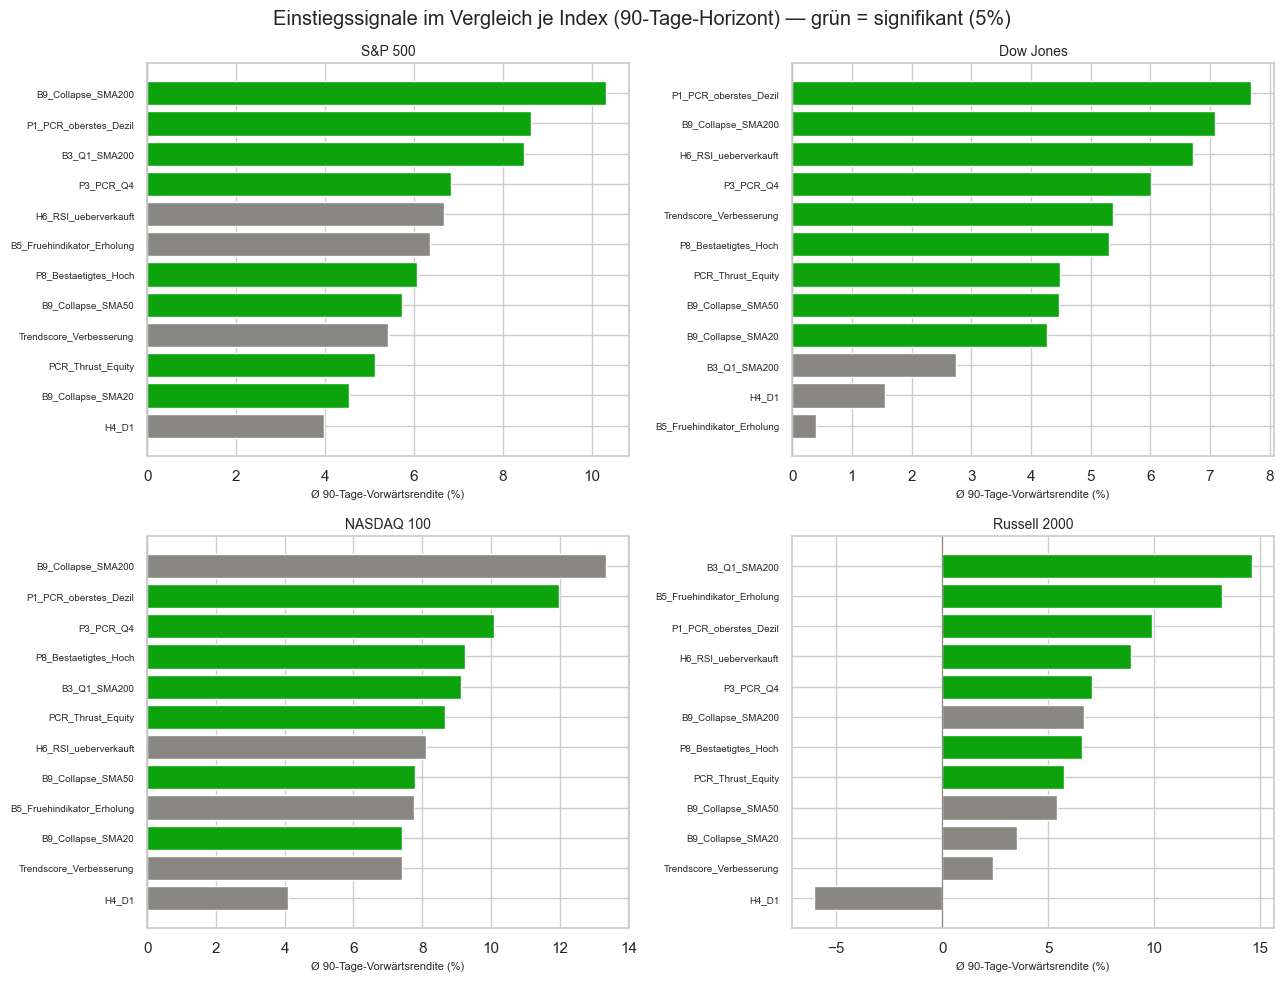

In [32]:
teil90 = tabelle_alle_signale[tabelle_alle_signale["horizont_tage"] == 90]
fig, achsen = plt.subplots(2, 2, figsize=(13, 10), sharex=False)
for achse, (idx_key, cfg) in zip(achsen.flat, INDICES.items()):
    teil_index = teil90[teil90["Index"] == cfg["name"]].sort_values("mean_return")
    farben = [COLOR_GOOD if s else COLOR_MUTED for s in teil_index["signifikant_5pct"]]
    achse.barh(teil_index["signal"], teil_index["mean_return"] * 100, color=farben)
    achse.axvline(0, color=COLOR_MUTED, linewidth=0.8)
    achse.set_title(cfg["name"], fontsize=10)
    achse.set_xlabel("Ø 90-Tage-Vorwärtsrendite (%)", fontsize=8)
    achse.tick_params(axis="y", labelsize=7)
fig.suptitle("Einstiegssignale im Vergleich je Index (90-Tage-Horizont) — grün = signifikant (5%)")
fig.tight_layout()
plt.show()

**Was zeigt dieses Diagramm und was bedeutet das für die Praxis?** Für jeden
der vier Indices ein eigenes Panel mit allen elf Mustern, sortiert nach
durchschnittlicher 90-Tage-Rendite; grün markierte Balken sind auf dem
5-%-Niveau statistisch signifikant. Für die Praxis lässt sich damit auf einen
Blick ablesen, welche Signale nur in einem Index auffällig sind (Vorsicht,
möglicherweise Zufall) und welche über mehrere oder alle vier Indices hinweg
konsistent grün sind — Letzteres ist der stärkere Beleg für ein tatsächlich
robustes, praktisch nutzbares Signal.

## 5. Strategie-Vergleich je Index: Ampel-Kombinationen im Test

Dieser Abschnitt beantwortet Blickwinkel 2 und 3 aus der Einleitung. Je Index
werden **vier** Varianten miteinander verglichen:

1. **Buy & Hold** — durchgehend investiert, keine Ein-/Ausstiege.
2. **Reine Ampel-Strategie** — investiert, außer während einer Rot-Phase (voller
   Ausstieg, Wiedereinstieg erst wenn die Ampel nicht mehr Rot ist).
3. **Ampel + früher Wiedereinstieg** (Blickwinkel 2) — wie die reine
   Ampel-Strategie, aber sobald **innerhalb einer laufenden Rot-Phase**
   mindestens einmal ein Einstiegssignal ausgelöst hat, gilt der Markt ab diesem
   Tag bis zum natürlichen Ende der Rot-Phase wieder als "wieder eingestiegen".
   Vor dem ersten Auslösen bleibt die Phase wie bei der reinen Ampel-Strategie
   ausgeschlossen.
4. **Signalgetriebene Strategie** (Blickwinkel 3) — hier ist der **Grundzustand
   nicht investiert**. Ein Einstiegssignal macht investiert, unabhängig von der
   aktuellen Ampelfarbe (auch mitten in einer laufenden Rot-Phase). Investiert
   bleibt man so lange, bis eine **neue** Rot-Phase beginnt — dann Ausstieg, bis
   ein neues Signal wieder einsteigt.

Als Einstiegssignal zählt für **jeden der vier Indices identisch**: das
A/D-Signal aus Abschnitt 3 (feste 70-%-Schwelle) **oder** eines der elf Muster
aus Abschnitt 4, jeweils für den betreffenden Index.

In [33]:
def schlecht_mit_fruehem_wiedereinstieg(ampel: pd.Series, signal: pd.Series) -> pd.Series:
    '''Variante 3 (Blickwinkel 2): Wie die reine Ampel (Ausschluss während
    Rot-Phasen), aber sobald innerhalb einer zusammenhängenden Rot-Phase
    mindestens einmal ein Einstiegssignal ausgelöst hat, gilt ab diesem Tag (bis
    zum Ende der Phase) wieder als investiert.'''
    rot = (ampel == "Rot").reindex(ampel.index).fillna(False)
    sig = signal.reindex(ampel.index).fillna(False)
    block_id = (rot != rot.shift(fill_value=False)).cumsum()
    sig_seit_phasenbeginn = sig.astype(int).groupby(block_id).cummax().astype(bool)
    return rot & ~sig_seit_phasenbeginn


def schlecht_signalgetrieben(ampel: pd.Series, signal: pd.Series) -> pd.Series:
    '''Variante 4 (Blickwinkel 3): Grundzustand nicht investiert. Ein
    Einstiegssignal macht investiert - unabhängig von der aktuellen Ampelfarbe,
    auch mitten in einer laufenden Rot-Phase. Ausstieg am ersten Tag einer NEUEN
    Rot-Phase, danach ist wieder ein Signal nötig.'''
    rot = (ampel == "Rot").reindex(ampel.index).fillna(False)
    sig = signal.reindex(ampel.index).fillna(False)
    neue_rot_phase = rot & ~rot.shift(1, fill_value=False)

    zustand = pd.Series(np.nan, index=ampel.index, dtype=object)
    zustand[neue_rot_phase] = False    # Ausstieg am ersten Tag einer neuen Rot-Phase
    zustand[sig] = True                # ein Signal am selben Tag gewinnt (sofortiger Wiedereinstieg)
    if pd.isna(zustand.iloc[0]):
        zustand.iloc[0] = False        # Startzustand: nicht investiert
    investiert = zustand.ffill().astype(bool)
    return ~investiert


# A/D-Signal (feste 70-%-Schwelle) je Index mit den Abschnitt-4-Mustern desselben Index verknüpfen.
fruehsignal_je_index: dict[str, pd.Series] = {}
for idx_key, df in index_daten.items():
    fruehsignal = ad_signal_alle_indices[idx_key].copy()
    for event in event_masken[idx_key].values():
        fruehsignal = fruehsignal | event.reindex(df.index).fillna(False)
    fruehsignal_je_index[idx_key] = fruehsignal
    print(f"{INDICES[idx_key]['name']}: {int(fruehsignal.sum()):,} kombinierte Signaltage "
          f"({fruehsignal.mean():.1%} aller Handelstage)")

S&P 500: 2,501 kombinierte Signaltage (50.7% aller Handelstage)
Dow Jones: 2,638 kombinierte Signaltage (53.5% aller Handelstage)
NASDAQ 100: 2,491 kombinierte Signaltage (50.5% aller Handelstage)
Russell 2000: 2,453 kombinierte Signaltage (49.7% aller Handelstage)


**Was wurde hier gemacht?** Zwei Funktionen für die Varianten 3 und 4 definiert
(siehe Erklärung oben) sowie für jeden Index eine gemeinsame Einstiegssignal-Maske
gebaut: das A/D-Signal aus Abschnitt 3, verknüpft mit einer ODER-Verknüpfung
aller in Abschnitt 4 berechneten Muster für genau diesen Index.

In [34]:
def kombi_kennzahlen(df: pd.DataFrame, ampel: pd.Series, signal: pd.Series, index_name: str) -> dict:
    www_ampel = was_waere_wenn(df, ampel == "Rot", f"{index_name}_Ampel")
    www_frueh = was_waere_wenn(df, schlecht_mit_fruehem_wiedereinstieg(ampel, signal),
                                f"{index_name}_Ampel_plus_Fruehsignal")
    www_signal = was_waere_wenn(df, schlecht_signalgetrieben(ampel, signal),
                                 f"{index_name}_Signalgetrieben")

    def kennzahlen(www: dict, rendite_key: str, cagr_key: str, mdd_key: str, tagesrendite_key: str) -> dict:
        return {
            "gesamtrendite": www[rendite_key], "cagr": www[cagr_key], "max_drawdown": www[mdd_key],
            "sharpe": sharpe_ratio(www[tagesrendite_key]), "equity": www["equity_" + tagesrendite_key.split("_", 1)[1]],
        }

    return {
        "buy_hold": kennzahlen(www_ampel, "gesamtrendite_buy_hold", "cagr_buy_hold",
                                "max_drawdown_buy_hold", "tagesrendite_buy_hold"),
        "ampel": kennzahlen(www_ampel, "gesamtrendite_strategie", "cagr_strategie",
                             "max_drawdown_strategie", "tagesrendite_strategie"),
        "ampel_fruehsignal": kennzahlen(www_frueh, "gesamtrendite_strategie", "cagr_strategie",
                                         "max_drawdown_strategie", "tagesrendite_strategie"),
        "signalgetrieben": kennzahlen(www_signal, "gesamtrendite_strategie", "cagr_strategie",
                                       "max_drawdown_strategie", "tagesrendite_strategie"),
    }


kombi_ergebnisse: dict[str, dict] = {}
for idx_key, df in index_daten.items():
    kombi_ergebnisse[idx_key] = kombi_kennzahlen(df, df["Ampel"], fruehsignal_je_index[idx_key], INDICES[idx_key]["name"])
print("Alle vier Strategie-Varianten für alle Indices berechnet.")

Alle vier Strategie-Varianten für alle Indices berechnet.


**Was wurde hier gemacht?** `kombi_kennzahlen` berechnet für einen Index alle
vier Varianten über die bereits bekannte `was_waere_wenn`-Simulation und fasst
Gesamtrendite, CAGR, Max Drawdown und Sharpe Ratio zusammen. Das Ergebnis für
alle vier Indices liegt jetzt in `kombi_ergebnisse` und wird in den folgenden
vier Unterabschnitten in je einem gemeinsamen Chart dargestellt.

### 5.1 S&P 500

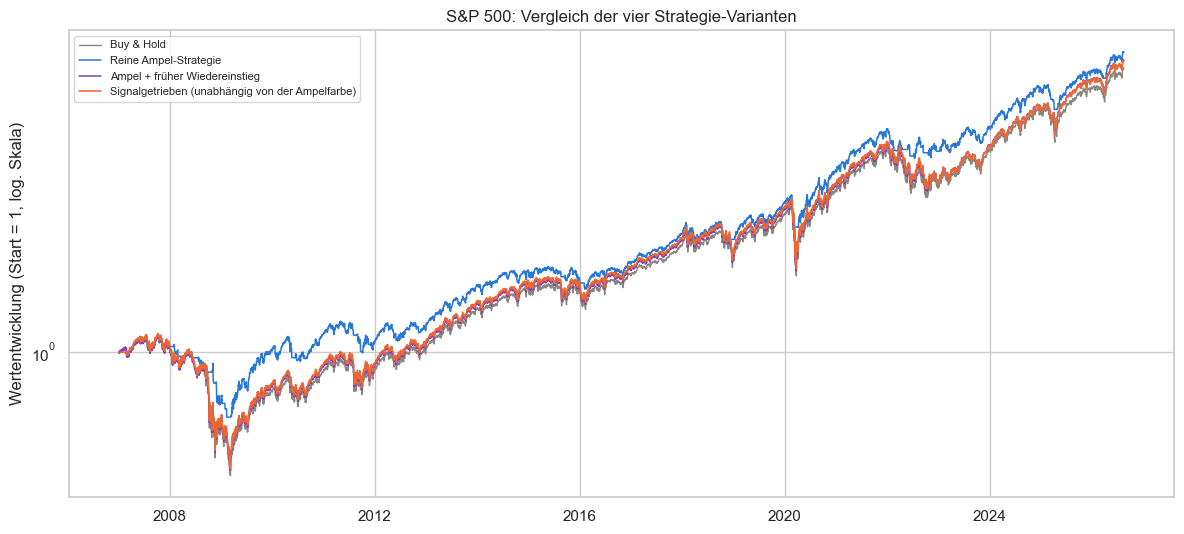

,Variante,Gesamtrendite,CAGR,Max Drawdown,Sharpe Ratio
0,Buy & Hold,4.4698,0.0905,-0.5678,0.5394
1,Reine Ampel-Strategie,5.0446,0.0961,-0.3863,0.7137
2,Ampel + früher Wiedereinstieg,4.7479,0.0933,-0.5544,0.5529
3,Signalgetrieben,4.7361,0.0932,-0.5544,0.5528


In [35]:
IDX_KEY = "SP500"
df = index_daten[IDX_KEY]
erg = kombi_ergebnisse[IDX_KEY]

fig, achse = plt.subplots(figsize=(12, 5.5))
achse.plot(df.index, erg["buy_hold"]["equity"], color=COLOR_MUTED, linewidth=1.0, label="Buy & Hold")
achse.plot(df.index, erg["ampel"]["equity"], color=COLOR_A, linewidth=1.1, label="Reine Ampel-Strategie")
achse.plot(df.index, erg["ampel_fruehsignal"]["equity"], color=COLOR_C, linewidth=1.1,
           label="Ampel + früher Wiedereinstieg")
achse.plot(df.index, erg["signalgetrieben"]["equity"], color=COLOR_B, linewidth=1.1,
           label="Signalgetrieben (unabhängig von der Ampelfarbe)")
achse.set_yscale("log")
achse.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
achse.set_title(f"{INDICES[IDX_KEY]['name']}: Vergleich der vier Strategie-Varianten")
achse.legend(fontsize=8)
fig.tight_layout()
plt.show()

kennzahlen_tabelle = pd.DataFrame({
    "Variante": ["Buy & Hold", "Reine Ampel-Strategie", "Ampel + früher Wiedereinstieg", "Signalgetrieben"],
    "Gesamtrendite": [erg[v]["gesamtrendite"] for v in ["buy_hold", "ampel", "ampel_fruehsignal", "signalgetrieben"]],
    "CAGR": [erg[v]["cagr"] for v in ["buy_hold", "ampel", "ampel_fruehsignal", "signalgetrieben"]],
    "Max Drawdown": [erg[v]["max_drawdown"] for v in ["buy_hold", "ampel", "ampel_fruehsignal", "signalgetrieben"]],
    "Sharpe Ratio": [erg[v]["sharpe"] for v in ["buy_hold", "ampel", "ampel_fruehsignal", "signalgetrieben"]],
})
display(kennzahlen_tabelle)

**Was zeigen Diagramm und Tabelle, und was bedeutet das für die Praxis?** Vier
unterschiedliche Ein-/Ausstiegssystematiken im direkten Vergleich (Startwert = 1,
logarithmische Skala): **Buy & Hold** (grau, kein Timing), **reine Ampel** (blau,
Ausstieg bei jeder Rot-Phase bis zu deren natürlichem Ende), **Ampel + früher
Wiedereinstieg** (violett, wie die Ampel, aber vorzeitiger Wiedereinstieg
innerhalb einer Rot-Phase sobald ein Einstiegssignal auslöst) und
**signalgetrieben** (orange, grundsätzlich nicht investiert, nur nach einem
Einstiegssignal investiert, Ausstieg bei jeder neuen Rot-Phase). Für die Praxis
zeigt der Vergleich, ob sich das aktive Timing überhaupt lohnt (Ampel-Varianten
vs. Buy & Hold) und ob ein zusätzliches Einstiegssignal den Max Drawdown weiter
senkt oder eher wieder in Richtung Buy & Hold zurückführt — je nachdem, wie oft
das kombinierte Signal auslöst, kann die zusätzliche Flexibilität den
Drawdown-Schutz der reinen Ampel auch wieder abschwächen.

### 5.2 Dow Jones

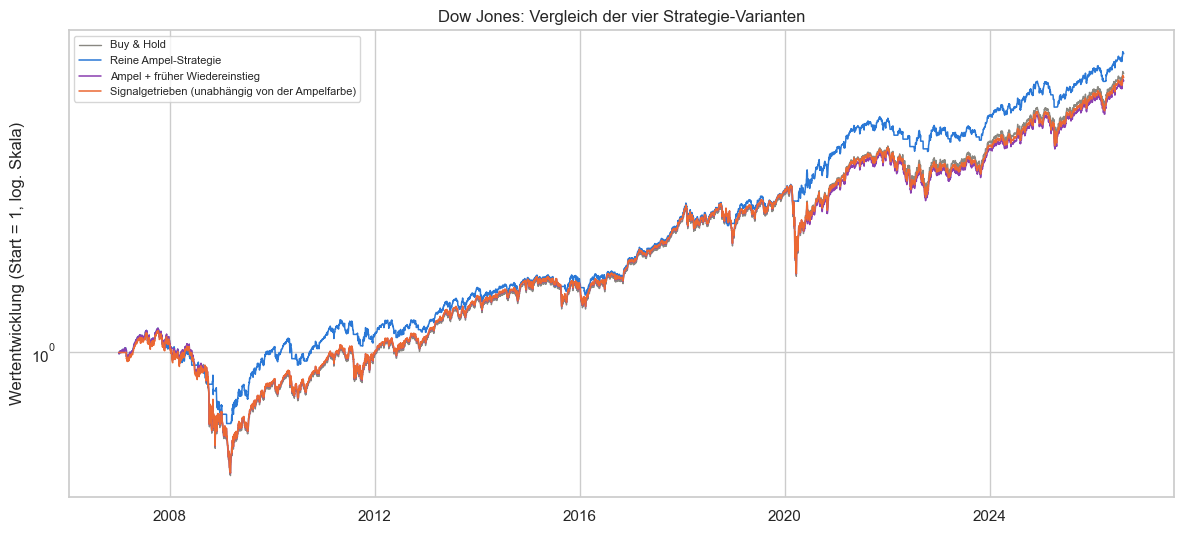

,Variante,Gesamtrendite,CAGR,Max Drawdown,Sharpe Ratio
0,Buy & Hold,3.3104,0.0774,-0.5378,0.4949
1,Reine Ampel-Strategie,3.7818,0.0831,-0.3928,0.6633
2,Ampel + früher Wiedereinstieg,3.1454,0.0752,-0.5322,0.4848
3,Signalgetrieben,3.2214,0.0762,-0.5253,0.4900


In [36]:
IDX_KEY = "DowJones"
df = index_daten[IDX_KEY]
erg = kombi_ergebnisse[IDX_KEY]

fig, achse = plt.subplots(figsize=(12, 5.5))
achse.plot(df.index, erg["buy_hold"]["equity"], color=COLOR_MUTED, linewidth=1.0, label="Buy & Hold")
achse.plot(df.index, erg["ampel"]["equity"], color=COLOR_A, linewidth=1.1, label="Reine Ampel-Strategie")
achse.plot(df.index, erg["ampel_fruehsignal"]["equity"], color=COLOR_C, linewidth=1.1,
           label="Ampel + früher Wiedereinstieg")
achse.plot(df.index, erg["signalgetrieben"]["equity"], color=COLOR_B, linewidth=1.1,
           label="Signalgetrieben (unabhängig von der Ampelfarbe)")
achse.set_yscale("log")
achse.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
achse.set_title(f"{INDICES[IDX_KEY]['name']}: Vergleich der vier Strategie-Varianten")
achse.legend(fontsize=8)
fig.tight_layout()
plt.show()

kennzahlen_tabelle = pd.DataFrame({
    "Variante": ["Buy & Hold", "Reine Ampel-Strategie", "Ampel + früher Wiedereinstieg", "Signalgetrieben"],
    "Gesamtrendite": [erg[v]["gesamtrendite"] for v in ["buy_hold", "ampel", "ampel_fruehsignal", "signalgetrieben"]],
    "CAGR": [erg[v]["cagr"] for v in ["buy_hold", "ampel", "ampel_fruehsignal", "signalgetrieben"]],
    "Max Drawdown": [erg[v]["max_drawdown"] for v in ["buy_hold", "ampel", "ampel_fruehsignal", "signalgetrieben"]],
    "Sharpe Ratio": [erg[v]["sharpe"] for v in ["buy_hold", "ampel", "ampel_fruehsignal", "signalgetrieben"]],
})
display(kennzahlen_tabelle)

**Was zeigen Diagramm und Tabelle, und was bedeutet das für die Praxis?** Vier
unterschiedliche Ein-/Ausstiegssystematiken im direkten Vergleich (Startwert = 1,
logarithmische Skala): **Buy & Hold** (grau, kein Timing), **reine Ampel** (blau,
Ausstieg bei jeder Rot-Phase bis zu deren natürlichem Ende), **Ampel + früher
Wiedereinstieg** (violett, wie die Ampel, aber vorzeitiger Wiedereinstieg
innerhalb einer Rot-Phase sobald ein Einstiegssignal auslöst) und
**signalgetrieben** (orange, grundsätzlich nicht investiert, nur nach einem
Einstiegssignal investiert, Ausstieg bei jeder neuen Rot-Phase). Für die Praxis
zeigt der Vergleich, ob sich das aktive Timing überhaupt lohnt (Ampel-Varianten
vs. Buy & Hold) und ob ein zusätzliches Einstiegssignal den Max Drawdown weiter
senkt oder eher wieder in Richtung Buy & Hold zurückführt — je nachdem, wie oft
das kombinierte Signal auslöst, kann die zusätzliche Flexibilität den
Drawdown-Schutz der reinen Ampel auch wieder abschwächen.

### 5.3 NASDAQ 100

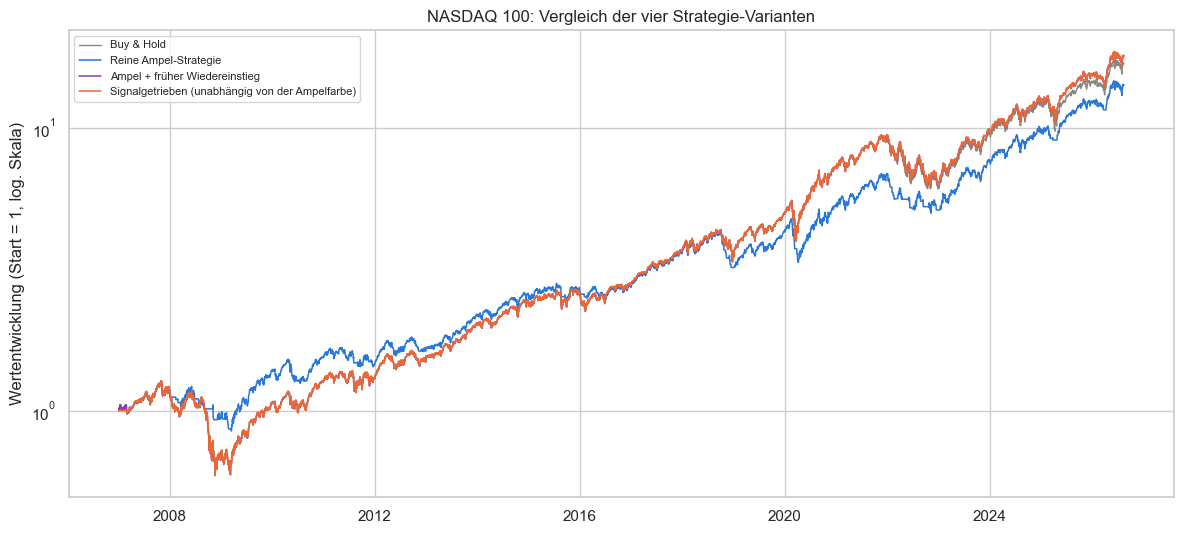

,Variante,Gesamtrendite,CAGR,Max Drawdown,Sharpe Ratio
0,Buy & Hold,15.9053,0.1551,-0.5371,0.7505
1,Reine Ampel-Strategie,13.1964,0.1449,-0.3347,0.8514
2,Ampel + früher Wiedereinstieg,16.9673,0.1587,-0.5371,0.7648
3,Signalgetrieben,16.9990,0.1588,-0.5371,0.7663


In [37]:
IDX_KEY = "NASDAQ100"
df = index_daten[IDX_KEY]
erg = kombi_ergebnisse[IDX_KEY]

fig, achse = plt.subplots(figsize=(12, 5.5))
achse.plot(df.index, erg["buy_hold"]["equity"], color=COLOR_MUTED, linewidth=1.0, label="Buy & Hold")
achse.plot(df.index, erg["ampel"]["equity"], color=COLOR_A, linewidth=1.1, label="Reine Ampel-Strategie")
achse.plot(df.index, erg["ampel_fruehsignal"]["equity"], color=COLOR_C, linewidth=1.1,
           label="Ampel + früher Wiedereinstieg")
achse.plot(df.index, erg["signalgetrieben"]["equity"], color=COLOR_B, linewidth=1.1,
           label="Signalgetrieben (unabhängig von der Ampelfarbe)")
achse.set_yscale("log")
achse.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
achse.set_title(f"{INDICES[IDX_KEY]['name']}: Vergleich der vier Strategie-Varianten")
achse.legend(fontsize=8)
fig.tight_layout()
plt.show()

kennzahlen_tabelle = pd.DataFrame({
    "Variante": ["Buy & Hold", "Reine Ampel-Strategie", "Ampel + früher Wiedereinstieg", "Signalgetrieben"],
    "Gesamtrendite": [erg[v]["gesamtrendite"] for v in ["buy_hold", "ampel", "ampel_fruehsignal", "signalgetrieben"]],
    "CAGR": [erg[v]["cagr"] for v in ["buy_hold", "ampel", "ampel_fruehsignal", "signalgetrieben"]],
    "Max Drawdown": [erg[v]["max_drawdown"] for v in ["buy_hold", "ampel", "ampel_fruehsignal", "signalgetrieben"]],
    "Sharpe Ratio": [erg[v]["sharpe"] for v in ["buy_hold", "ampel", "ampel_fruehsignal", "signalgetrieben"]],
})
display(kennzahlen_tabelle)

**Was zeigen Diagramm und Tabelle, und was bedeutet das für die Praxis?** Vier
unterschiedliche Ein-/Ausstiegssystematiken im direkten Vergleich (Startwert = 1,
logarithmische Skala): **Buy & Hold** (grau, kein Timing), **reine Ampel** (blau,
Ausstieg bei jeder Rot-Phase bis zu deren natürlichem Ende), **Ampel + früher
Wiedereinstieg** (violett, wie die Ampel, aber vorzeitiger Wiedereinstieg
innerhalb einer Rot-Phase sobald ein Einstiegssignal auslöst) und
**signalgetrieben** (orange, grundsätzlich nicht investiert, nur nach einem
Einstiegssignal investiert, Ausstieg bei jeder neuen Rot-Phase). Für die Praxis
zeigt der Vergleich, ob sich das aktive Timing überhaupt lohnt (Ampel-Varianten
vs. Buy & Hold) und ob ein zusätzliches Einstiegssignal den Max Drawdown weiter
senkt oder eher wieder in Richtung Buy & Hold zurückführt — je nachdem, wie oft
das kombinierte Signal auslöst, kann die zusätzliche Flexibilität den
Drawdown-Schutz der reinen Ampel auch wieder abschwächen.

### 5.4 Russell 2000

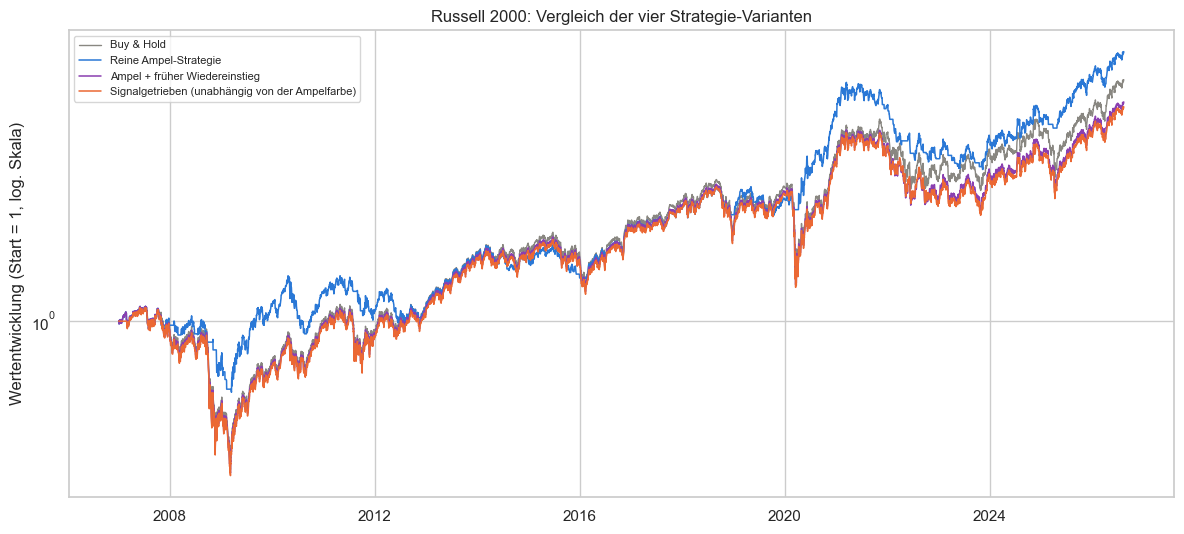

,Variante,Gesamtrendite,CAGR,Max Drawdown,Sharpe Ratio
0,Buy & Hold,2.8677,0.0714,-0.5989,0.4011
1,Reine Ampel-Strategie,3.5253,0.0800,-0.3858,0.4958
2,Ampel + früher Wiedereinstieg,2.4143,0.0646,-0.6068,0.3760
3,Signalgetrieben,2.3230,0.0632,-0.6099,0.3707


In [38]:
IDX_KEY = "Russell2000"
df = index_daten[IDX_KEY]
erg = kombi_ergebnisse[IDX_KEY]

fig, achse = plt.subplots(figsize=(12, 5.5))
achse.plot(df.index, erg["buy_hold"]["equity"], color=COLOR_MUTED, linewidth=1.0, label="Buy & Hold")
achse.plot(df.index, erg["ampel"]["equity"], color=COLOR_A, linewidth=1.1, label="Reine Ampel-Strategie")
achse.plot(df.index, erg["ampel_fruehsignal"]["equity"], color=COLOR_C, linewidth=1.1,
           label="Ampel + früher Wiedereinstieg")
achse.plot(df.index, erg["signalgetrieben"]["equity"], color=COLOR_B, linewidth=1.1,
           label="Signalgetrieben (unabhängig von der Ampelfarbe)")
achse.set_yscale("log")
achse.set_ylabel("Wertentwicklung (Start = 1, log. Skala)")
achse.set_title(f"{INDICES[IDX_KEY]['name']}: Vergleich der vier Strategie-Varianten")
achse.legend(fontsize=8)
fig.tight_layout()
plt.show()

kennzahlen_tabelle = pd.DataFrame({
    "Variante": ["Buy & Hold", "Reine Ampel-Strategie", "Ampel + früher Wiedereinstieg", "Signalgetrieben"],
    "Gesamtrendite": [erg[v]["gesamtrendite"] for v in ["buy_hold", "ampel", "ampel_fruehsignal", "signalgetrieben"]],
    "CAGR": [erg[v]["cagr"] for v in ["buy_hold", "ampel", "ampel_fruehsignal", "signalgetrieben"]],
    "Max Drawdown": [erg[v]["max_drawdown"] for v in ["buy_hold", "ampel", "ampel_fruehsignal", "signalgetrieben"]],
    "Sharpe Ratio": [erg[v]["sharpe"] for v in ["buy_hold", "ampel", "ampel_fruehsignal", "signalgetrieben"]],
})
display(kennzahlen_tabelle)

**Was zeigen Diagramm und Tabelle, und was bedeutet das für die Praxis?** Vier
unterschiedliche Ein-/Ausstiegssystematiken im direkten Vergleich (Startwert = 1,
logarithmische Skala): **Buy & Hold** (grau, kein Timing), **reine Ampel** (blau,
Ausstieg bei jeder Rot-Phase bis zu deren natürlichem Ende), **Ampel + früher
Wiedereinstieg** (violett, wie die Ampel, aber vorzeitiger Wiedereinstieg
innerhalb einer Rot-Phase sobald ein Einstiegssignal auslöst) und
**signalgetrieben** (orange, grundsätzlich nicht investiert, nur nach einem
Einstiegssignal investiert, Ausstieg bei jeder neuen Rot-Phase). Für die Praxis
zeigt der Vergleich, ob sich das aktive Timing überhaupt lohnt (Ampel-Varianten
vs. Buy & Hold) und ob ein zusätzliches Einstiegssignal den Max Drawdown weiter
senkt oder eher wieder in Richtung Buy & Hold zurückführt — je nachdem, wie oft
das kombinierte Signal auslöst, kann die zusätzliche Flexibilität den
Drawdown-Schutz der reinen Ampel auch wieder abschwächen.

## 6. Export der Ergebnisse

Alle Ergebnisse werden als Excel-Arbeitsmappe und als CSV-Dateien
gespeichert: die A/D-Kreuzauswertung aus Abschnitt 3, die vollständige
Signaltabelle aus Abschnitt 4 sowie je Index eine Übersicht der vier verglichenen
Strategie-Varianten aus Abschnitt 5.

In [39]:
xlsx_pfad = EXPORT_DIR / "Einstiegssignale_Zusammenfassung.xlsx"
with pd.ExcelWriter(xlsx_pfad, engine="openpyxl") as writer:
    ad_niveau_tabelle.to_excel(writer, sheet_name="AD_Kreuzauswertung", index=False)
    tabelle_alle_signale.to_excel(writer, sheet_name="Einstiegssignale_alle_Indices", index=False)
    for idx_key, erg in kombi_ergebnisse.items():
        zeilen = []
        for variante, werte in erg.items():
            zeilen.append({
                "variante": variante, "gesamtrendite": werte["gesamtrendite"], "cagr": werte["cagr"],
                "max_drawdown": werte["max_drawdown"], "sharpe": werte["sharpe"],
            })
        pd.DataFrame(zeilen).to_excel(writer, sheet_name=f"{idx_key}_Strategien"[:31], index=False)

ad_niveau_tabelle.to_csv(EXPORT_DIR / "AD_Kreuzauswertung.csv", index=False)
tabelle_alle_signale.to_csv(EXPORT_DIR / "Einstiegssignale_alle_Indices.csv", index=False)

print(f"Excel-Arbeitsmappe gespeichert: {xlsx_pfad}")
print(f"Weitere CSV-Dateien im Ordner: {EXPORT_DIR.resolve()}")

Excel-Arbeitsmappe gespeichert: Hypothesenanalysen_Einstiegssignale\Einstiegssignale_Zusammenfassung.xlsx
Weitere CSV-Dateien im Ordner: C:\Users\ramos\OneDrive\Privat\Data Science Institute\Abschlussprojekt\Projektzusammenführung\Einstiegssignale\Hypothesenanalysen_Einstiegssignale


Damit stehen alle Kennzahlen aus Abschnitt 3 bis 5 auch außerhalb des
Notebooks zur Verfügung — für die Praxis insbesondere nützlich, um die
Kreuzauswertung aus Abschnitt 3 in einer eigenen Tabellenkalkulation weiter zu
filtern oder zu sortieren.

## 7. Zusammenfassung

**Blickwinkel 1 (isolierte Signale, Abschnitt 3 und 4):** Sowohl das
Advancing/Declining-Kapitulationssignal als auch mehrere der elf tabellierten
Muster — insbesondere die Put/Call-Ratio-Kontraindikatoren — zeigen über mehrere
Indices und Horizonte hinweg konsistent positive, teils statistisch signifikante
Mehrrenditen gegenüber der Basisrate. Andere Muster (z. B. H4, B5) sind wegen
geringer Ereigniszahl eher deskriptiv zu werten.

**Blickwinkel 2 und 3 (kombiniert mit der Ampel, Abschnitt 5):** Der Vergleich
der vier Strategie-Varianten zeigt je Index, ob sich aktives Timing über Buy &
Hold hinaus lohnt, und ob ein zusätzliches Einstiegssignal — sei es als früher
Wiedereinstieg innerhalb einer Rot-Phase oder als eigenständiger,
signalgetriebener Auslöser — den Max Drawdown der reinen Ampel-Strategie weiter
senkt oder ihn eher wieder in Richtung Buy & Hold aufweicht. Die
vollständigen Kennzahlen für alle vier Indices sind im Exportordner
`Hypothesenanalysen_Einstiegssignale/` dokumentiert.